# Expression Data Exploratory Data Analysis

This notebook performs comprehensive EDA on expression data (TPM) and covariates.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Create figures directory if it doesn't exist
import os
#os.makedirs('figures', exist_ok=True)


## 1. Load Data


In [6]:
# Load expression data
tpm_file = "/gpfs/commons/groups/knowles_lab/vmazeeva/BigBrain/Processed/tpm.tsv"
covariates_file = "/gpfs/commons/groups/knowles_lab/vmazeeva/BigBrain/Processed/covariates.tsv"

print("Loading expression data...")
tpm_df = pd.read_csv(tpm_file, sep='\t', index_col=0)
print(f"Expression data shape: {tpm_df.shape}")
print(f"Samples (columns): {tpm_df.shape[1]}, Genes (rows): {tpm_df.shape[0]}")

print("\nLoading covariates...")
covariates_df = pd.read_csv(covariates_file, sep='\t', index_col=0)
print(f"Covariates shape: {covariates_df.shape}")
print(f"Samples: {covariates_df.shape[0]}, Covariates: {covariates_df.shape[1]}")

# Check overlap
common_samples = set(tpm_df.columns) & set(covariates_df.index)
print(f"\nCommon samples: {len(common_samples)}")
print(f"Samples only in expression: {len(set(tpm_df.columns) - set(covariates_df.index))}")
print(f"Samples only in covariates: {len(set(covariates_df.index) - set(tpm_df.columns))}")


Loading expression data...


Expression data shape: (58929, 7965)
Samples (columns): 7965, Genes (rows): 58929

Loading covariates...
Covariates shape: (7965, 202)
Samples: 7965, Covariates: 202

Common samples: 7965
Samples only in expression: 0
Samples only in covariates: 0


In [5]:
tpm_file = "/gpfs/commons/groups/knowles_lab/vmazeeva/BigBrain/Processed/tpm.tsv"
tpm_df = pd.read_csv(tpm_file, sep='\t').set_index('feature')

In [6]:
tpm_df

,CASE-NEUAE810KF7-9607-T,CASE-NEUAK233YVY-9803-T,CASE-NEUAL614GYB-8618-T,CASE-NEUAN180JPP-10533-T,CASE-NEUAP460GUX-10708-T,CASE-NEUAT541XCN-10596-T,CASE-NEUAV181KYK-10631-T,CASE-NEUAW339DLB-8198-T,CASE-NEUAW408VMD-8380-T,CASE-NEUBB467PKE-10055-T,...,RISK_42_rerun_S121,RISK_46_rerun_S123,RISK_48_S67,RISK_4_S18,RISK_6_S20,RISK_8_rerun_S112,SM-AYOPW.final,SM-AYOQN.final,SM-CSEEA.final,SM-D3ERK.final
feature,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003.14,1.56,3.71,2.78,10.27,5.84,12.90,5.23,3.20,2.03,7.91,...,2.32,1.01,1.56,0.71,0.77,0.66,2.02,1.41,1.27,0.91
ENSG00000000005.6,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.06,0.00,0.06,0.00,0.04,0.00,0.00,0.00,0.00
ENSG00000000419.12,9.04,8.74,9.77,7.93,6.46,12.61,7.63,8.13,9.16,13.55,...,3.14,2.95,3.31,1.91,2.97,1.87,2.80,5.24,1.97,1.73
ENSG00000000457.14,0.72,1.38,0.56,1.91,1.46,1.88,1.74,1.01,0.38,2.20,...,1.39,1.02,0.97,1.09,0.67,0.55,0.25,0.57,0.47,0.14
ENSG00000000460.17,0.73,0.77,0.77,1.08,0.84,1.46,0.83,0.81,0.68,1.45,...,1.88,1.35,1.26,0.41,0.36,0.67,0.28,0.78,0.38,0.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000286268.1,0.05,0.16,0.15,0.07,0.05,0.05,0.17,0.05,0.11,0.09,...,0.00,0.27,0.09,0.00,0.11,0.05,0.00,0.11,0.00,0.04
ENSG00000286269.1,0.01,0.00,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.01,...,0.30,0.01,0.01,0.15,0.01,0.04,0.31,0.10,0.01,0.03
ENSG00000286270.1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [14]:
tpm_df['gene'] = tpm_df.index.str.split('.').str[0]
tpm_df.set_index('gene', inplace=True)
tpm_df.index.name = 'feature'

In [15]:
tpm_df

,CASE-NEUAE810KF7-9607-T,CASE-NEUAK233YVY-9803-T,CASE-NEUAL614GYB-8618-T,CASE-NEUAN180JPP-10533-T,CASE-NEUAP460GUX-10708-T,CASE-NEUAT541XCN-10596-T,CASE-NEUAV181KYK-10631-T,CASE-NEUAW339DLB-8198-T,CASE-NEUAW408VMD-8380-T,CASE-NEUBB467PKE-10055-T,...,RISK_42_rerun_S121,RISK_46_rerun_S123,RISK_48_S67,RISK_4_S18,RISK_6_S20,RISK_8_rerun_S112,SM-AYOPW.final,SM-AYOQN.final,SM-CSEEA.final,SM-D3ERK.final
feature,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,1.56,3.71,2.78,10.27,5.84,12.90,5.23,3.20,2.03,7.91,...,2.32,1.01,1.56,0.71,0.77,0.66,2.02,1.41,1.27,0.91
ENSG00000000005,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.06,0.00,0.06,0.00,0.04,0.00,0.00,0.00,0.00
ENSG00000000419,9.04,8.74,9.77,7.93,6.46,12.61,7.63,8.13,9.16,13.55,...,3.14,2.95,3.31,1.91,2.97,1.87,2.80,5.24,1.97,1.73
ENSG00000000457,0.72,1.38,0.56,1.91,1.46,1.88,1.74,1.01,0.38,2.20,...,1.39,1.02,0.97,1.09,0.67,0.55,0.25,0.57,0.47,0.14
ENSG00000000460,0.73,0.77,0.77,1.08,0.84,1.46,0.83,0.81,0.68,1.45,...,1.88,1.35,1.26,0.41,0.36,0.67,0.28,0.78,0.38,0.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000286268,0.05,0.16,0.15,0.07,0.05,0.05,0.17,0.05,0.11,0.09,...,0.00,0.27,0.09,0.00,0.11,0.05,0.00,0.11,0.00,0.04
ENSG00000286269,0.01,0.00,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.01,...,0.30,0.01,0.01,0.15,0.01,0.04,0.31,0.10,0.01,0.03
ENSG00000286270,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [11]:
genes = ['ENSG00000017797', 'ENSG00000286271', 'ENSG00000000457']

In [12]:
tpm_filtered = tpm_df[tpm_df.index.isin(genes)]
tpm_filtered


,CASE-NEUAE810KF7-9607-T,CASE-NEUAK233YVY-9803-T,CASE-NEUAL614GYB-8618-T,CASE-NEUAN180JPP-10533-T,CASE-NEUAP460GUX-10708-T,CASE-NEUAT541XCN-10596-T,CASE-NEUAV181KYK-10631-T,CASE-NEUAW339DLB-8198-T,CASE-NEUAW408VMD-8380-T,CASE-NEUBB467PKE-10055-T,...,RISK_42_rerun_S121,RISK_46_rerun_S123,RISK_48_S67,RISK_4_S18,RISK_6_S20,RISK_8_rerun_S112,SM-AYOPW.final,SM-AYOQN.final,SM-CSEEA.final,SM-D3ERK.final
gene,,,,,,,,,,,,,,,,,,,,,
ENSG00000000457,0.72,1.38,0.56,1.91,1.46,1.88,1.74,1.01,0.38,2.20,...,1.39,1.02,0.97,1.09,0.67,0.55,0.25,0.57,0.47,0.14
ENSG00000017797,5.36,4.10,3.18,4.84,3.84,6.62,4.89,4.36,3.70,6.65,...,10.22,6.68,5.75,4.94,4.85,5.76,5.11,8.87,4.35,6.85
ENSG00000286271,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,...,0.00,0.04,0.00,0.00,0.00,0.03,0.09,0.00,0.02,0.00


In [9]:
samples = ['CASE-NEUAE810KF7-9607-T', 'CASE-NEUAK233YVY-9803-T', 'CASE-NEUAL614GYB-8618-T']
df = tpm_df[samples]


In [13]:
df = df.T
df = df.rename(columns={'feature': 'sample_id'}, inplace=True)
df = df.set_index('sample_id')
df


AttributeError: 'NoneType' object has no attribute 'set_index'

## 2. Basic Data Statistics


In [3]:
print("=== Expression Data Summary ===")
print(f"Total genes: {tpm_df.shape[0]}")
print(f"Total samples: {tpm_df.shape[1]}")
print(f"Missing values: {tpm_df.isna().sum().sum()} ({100*tpm_df.isna().sum().sum()/(tpm_df.shape[0]*tpm_df.shape[1]):.2f}%)")
print(f"Zero values: {(tpm_df == 0).sum().sum()} ({100*(tpm_df == 0).sum().sum()/(tpm_df.shape[0]*tpm_df.shape[1]):.2f}%)")
expr_values = tpm_df.values.flatten()
expr_values = expr_values[~np.isnan(expr_values)]
print(f"\nExpression value statistics:")
print(pd.Series(expr_values).describe())



=== Expression Data Summary ===
Total genes: 58929
Total samples: 7255
Missing values: 0 (0.00%)
Zero values: 225464417 (52.74%)

Expression value statistics:
count    4.275299e+08
mean     1.696957e+01
std      1.551861e+03
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      9.200000e-01
max      5.955117e+05
dtype: float64


## 3. Expression Distribution Analysis


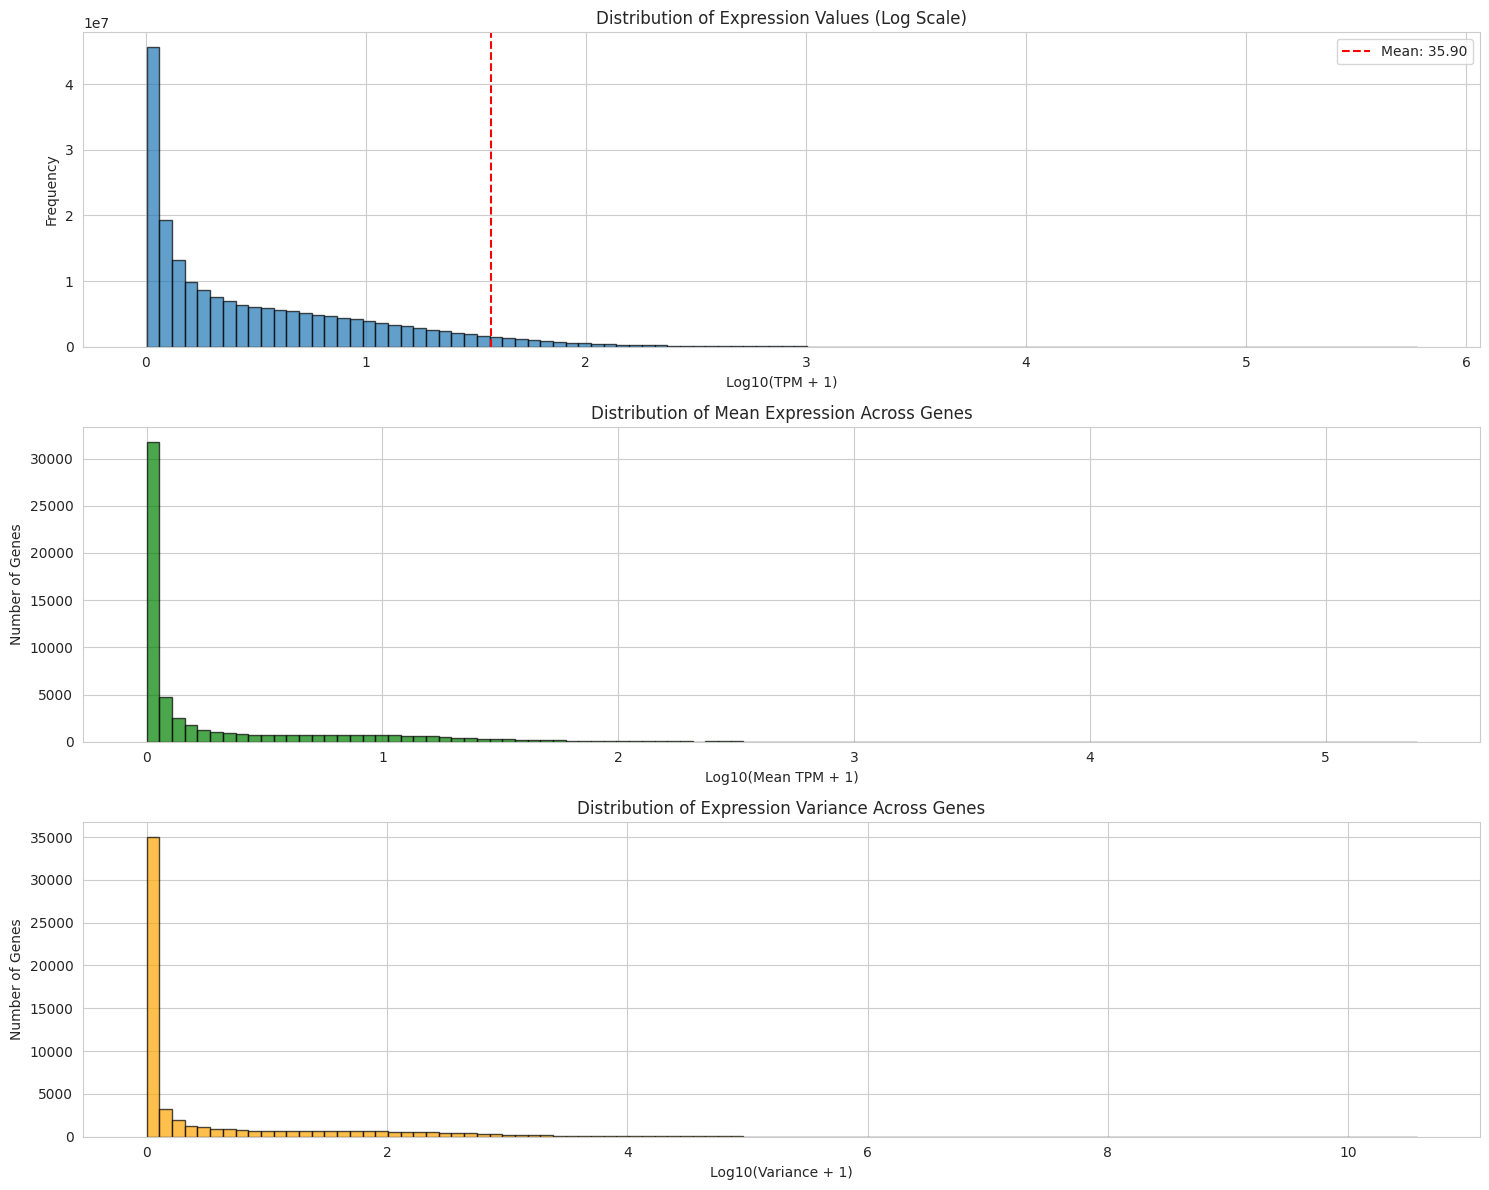

In [4]:
# Distribution of expression values
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# 1. Histogram of all expression values (log scale)
expr_values = tpm_df.values.flatten()
expr_values = expr_values[~np.isnan(expr_values)]
expr_values = expr_values[expr_values > 0]  # Remove zeros for log

axes[0].hist(np.log10(expr_values + 1), bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Log10(TPM + 1)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Expression Values (Log Scale)')
axes[0].axvline(np.log10(expr_values.mean() + 1), color='red', linestyle='--', label=f'Mean: {expr_values.mean():.2f}')
axes[0].legend()

# 3. Distribution of mean expression per gene
gene_means = tpm_df.mean(axis=1)
axes[1].hist(np.log10(gene_means + 1), bins=100, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Log10(Mean TPM + 1)')
axes[1].set_ylabel('Number of Genes')
axes[1].set_title('Distribution of Mean Expression Across Genes')

# 4. Distribution of variance per gene
gene_vars = tpm_df.var(axis=1)
axes[2].hist(np.log10(gene_vars + 1), bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[2].set_xlabel('Log10(Variance + 1)')
axes[2].set_ylabel('Number of Genes')
axes[2].set_title('Distribution of Expression Variance Across Genes')

plt.tight_layout()
plt.savefig('figures/expression_all_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


## 4. Filter Genes


In [3]:
# Subset genes (filter those with > 50% zero expression)
zero_fraction = (tpm_df == 0).sum(axis=1) / tpm_df.shape[1]
tpm_df_filtered = tpm_df.loc[zero_fraction < 0.5]

print("Number of genes before filtering: ", tpm_df.shape[0])
print("Number of genes after filtering: ", tpm_df_filtered.shape[0])

print(f"Filtered {tpm_df.shape[0] - tpm_df_filtered.shape[0]} genes ({(tpm_df.shape[0] - tpm_df_filtered.shape[0])/tpm_df.shape[0]*100:.2f}%)")

Number of genes before filtering:  58929
Number of genes after filtering:  26240
Filtered 32689 genes (55.47%)


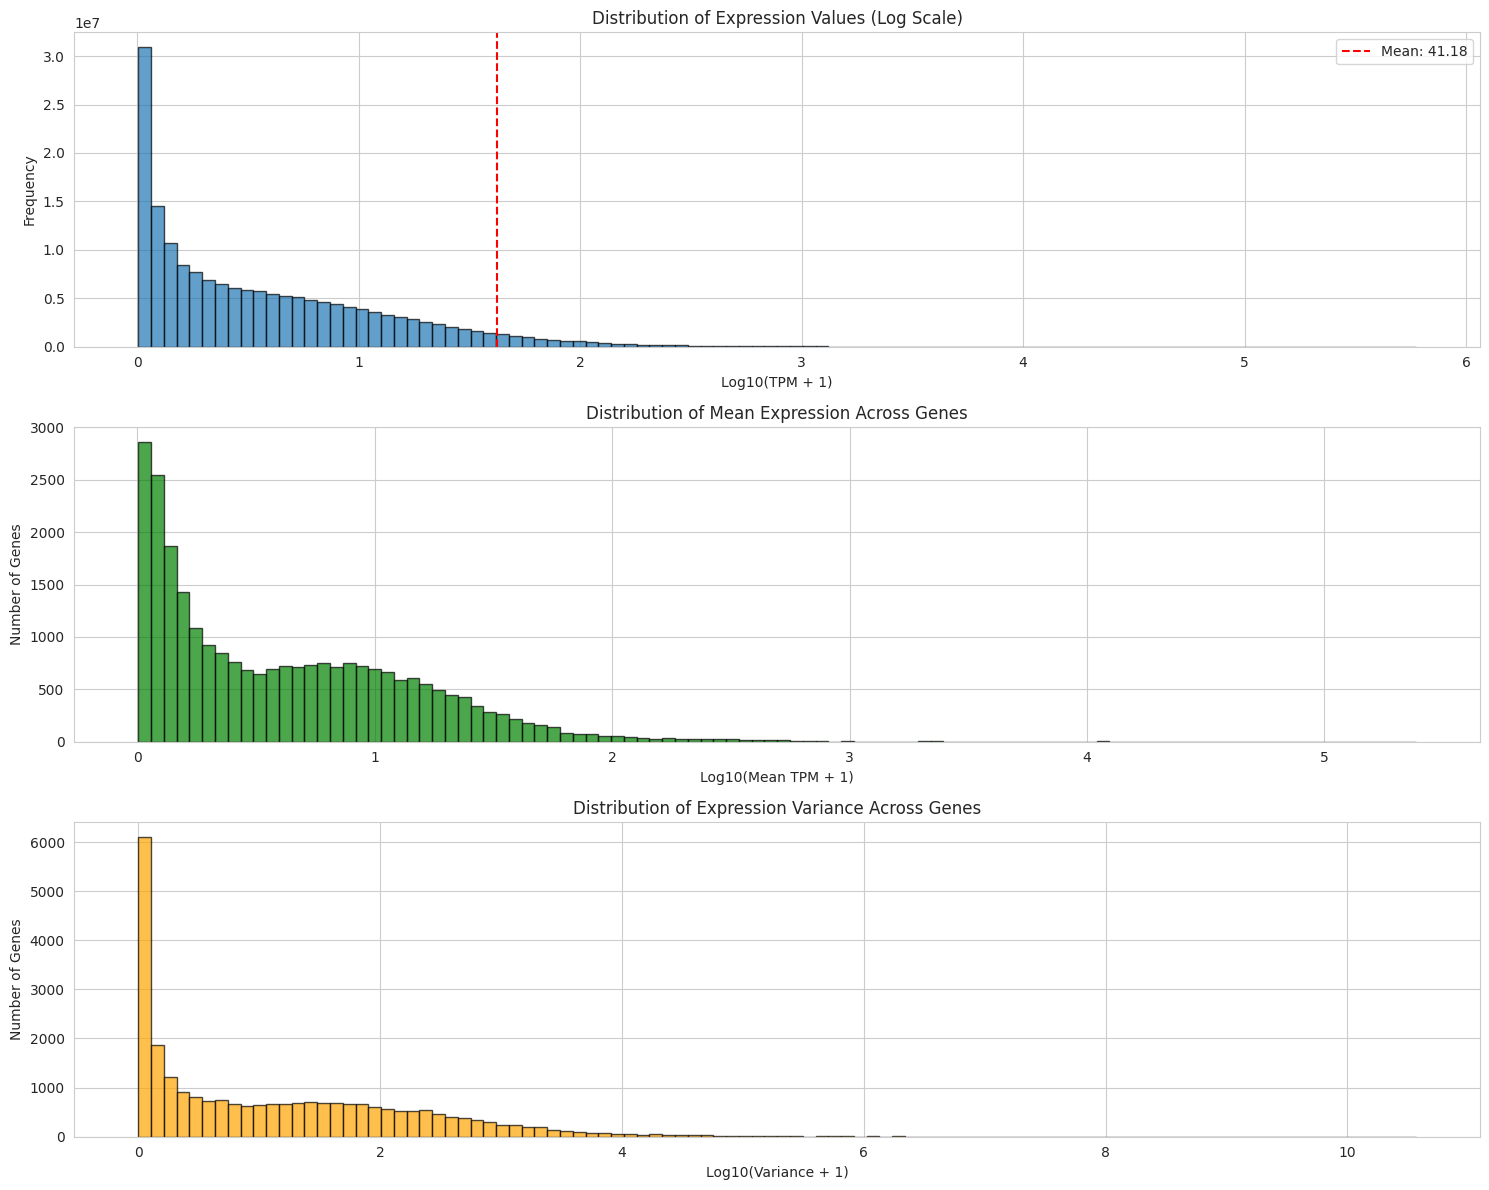

In [6]:
# Distribution of expression values
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# 1. Histogram of all expression values (log scale)
expr_values = tpm_df_filtered.values.flatten()
expr_values = expr_values[~np.isnan(expr_values)]
expr_values = expr_values[expr_values > 0]  # Remove zeros for log

axes[0].hist(np.log10(expr_values + 1), bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Log10(TPM + 1)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Expression Values (Log Scale)')
axes[0].axvline(np.log10(expr_values.mean() + 1), color='red', linestyle='--', label=f'Mean: {expr_values.mean():.2f}')
axes[0].legend()

# 3. Distribution of mean expression per gene
gene_means = tpm_df_filtered.mean(axis=1)
axes[1].hist(np.log10(gene_means + 1), bins=100, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Log10(Mean TPM + 1)')
axes[1].set_ylabel('Number of Genes')
axes[1].set_title('Distribution of Mean Expression Across Genes')

# 4. Distribution of variance per gene
gene_vars = tpm_df_filtered.var(axis=1)
axes[2].hist(np.log10(gene_vars + 1), bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[2].set_xlabel('Log10(Variance + 1)')
axes[2].set_ylabel('Number of Genes')
axes[2].set_title('Distribution of Expression Variance Across Genes')

plt.tight_layout()
plt.savefig('figures/expression_filtered_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. Principal Component Analysis (PCA)


### Original data

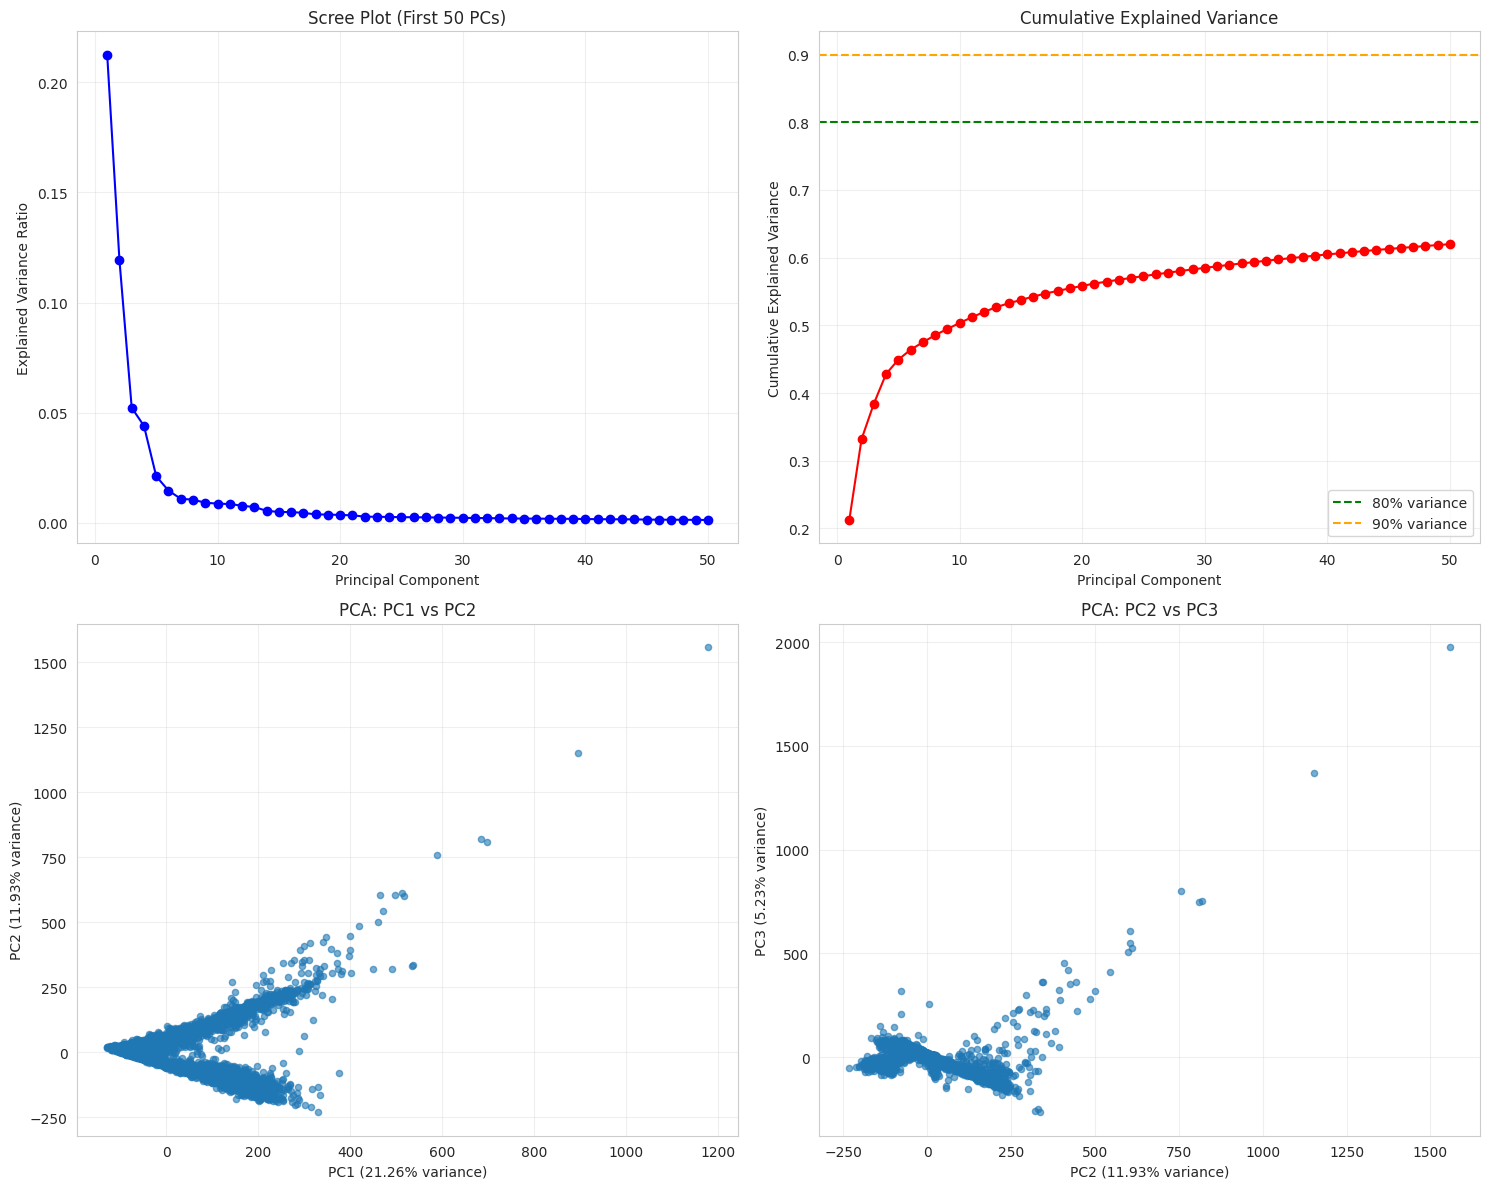

First 10 PCs explain 50.35% of variance
First 50 PCs explain 62.00% of variance
Number of PCs to explain 80% variance: 501
Number of PCs to explain 90% variance: 1477


In [4]:
# Prepare data for PCA
tpm = tpm_df.T  # Transpose: samples x genes 
scaler = StandardScaler()
tpm_scaled = scaler.fit_transform(tpm)

# Perform PCA
pca = PCA()
pca_result_original = pca.fit_transform(tpm_scaled)

# Plot explained variance
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Scree plot
n_components_plot = min(50, len(pca.explained_variance_ratio_))
axes[0, 0].plot(range(1, n_components_plot + 1), 
                pca.explained_variance_ratio_[:n_components_plot], 'bo-')
axes[0, 0].set_xlabel('Principal Component')
axes[0, 0].set_ylabel('Explained Variance Ratio')
axes[0, 0].set_title('Scree Plot (First 50 PCs)')
axes[0, 0].grid(True, alpha=0.3)

# Cumulative explained variance
cumulative_var = np.cumsum(pca.explained_variance_ratio_)
axes[0, 1].plot(range(1, n_components_plot + 1), 
                cumulative_var[:n_components_plot], 'ro-')
axes[0, 1].set_xlabel('Principal Component')
axes[0, 1].set_ylabel('Cumulative Explained Variance')
axes[0, 1].set_title('Cumulative Explained Variance')
axes[0, 1].axhline(0.8, color='green', linestyle='--', label='80% variance')
axes[0, 1].axhline(0.9, color='orange', linestyle='--', label='90% variance')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 2. PCA plot (PC1 vs PC2)
scatter = axes[1, 0].scatter(pca_result_original[:, 0], pca_result_original[:, 1], alpha=0.6, s=20)
axes[1, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
axes[1, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
axes[1, 0].set_title('PCA: PC1 vs PC2')
axes[1, 0].grid(True, alpha=0.3)

# 3. PCA plot (PC2 vs PC3)
scatter = axes[1, 1].scatter(pca_result_original[:, 1], pca_result_original[:, 2], alpha=0.6, s=20)
axes[1, 1].set_xlabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
axes[1, 1].set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.2f}% variance)')
axes[1, 1].set_title('PCA: PC2 vs PC3')
axes[1, 1].grid(True, alpha=0.3)


print(f"First 10 PCs explain {cumulative_var[9]*100:.2f}% of variance")
print(f"First 50 PCs explain {cumulative_var[49]*100:.2f}% of variance")
print(f"Number of PCs to explain 80% variance: {np.argmax(cumulative_var >= 0.8) + 1}")
print(f"Number of PCs to explain 90% variance: {np.argmax(cumulative_var >= 0.9) + 1}")


### Remove genes with zero expression for more than 50% of samples

First 10 PCs explain 71.67% of variance
First 50 PCs explain 82.53% of variance
Number of PCs to explain 80% variance: 31
Number of PCs to explain 90% variance: 352


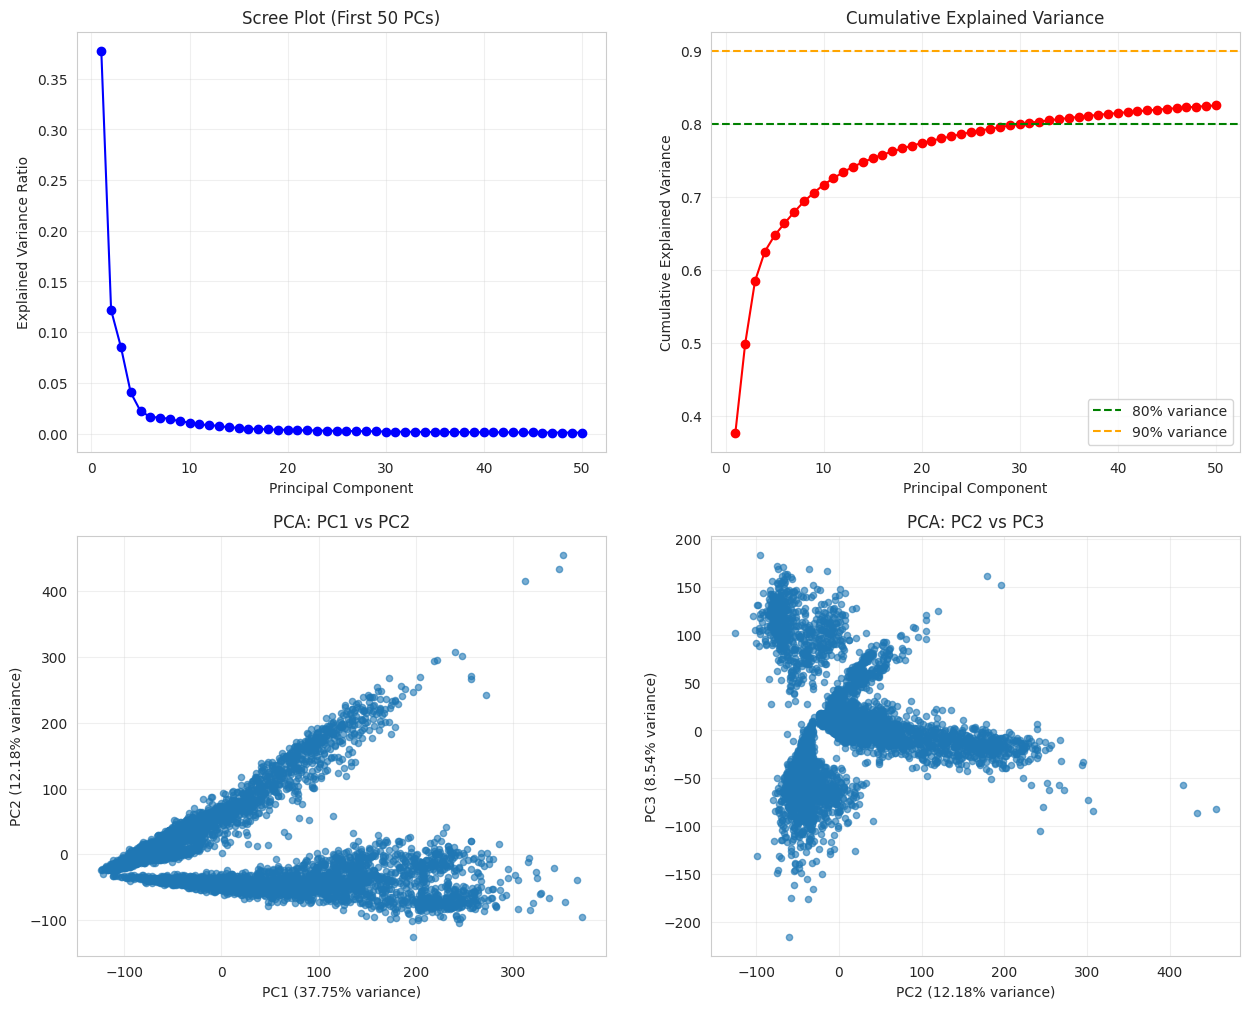

In [5]:
# Prepare data for PCA
# Use filtered data
tpm = tpm_df_filtered.T  # Transpose: samples x genes 
scaler = StandardScaler()
tpm_scaled = scaler.fit_transform(tpm)

# Perform PCA
pca = PCA()
pca_result_filtered = pca.fit_transform(tpm_scaled)

# Plot explained variance
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Scree plot
n_components_plot = min(50, len(pca.explained_variance_ratio_))
axes[0, 0].plot(range(1, n_components_plot + 1), 
                pca.explained_variance_ratio_[:n_components_plot], 'bo-')
axes[0, 0].set_xlabel('Principal Component')
axes[0, 0].set_ylabel('Explained Variance Ratio')
axes[0, 0].set_title('Scree Plot (First 50 PCs)')
axes[0, 0].grid(True, alpha=0.3)

# Cumulative explained variance
cumulative_var = np.cumsum(pca.explained_variance_ratio_)
axes[0, 1].plot(range(1, n_components_plot + 1), 
                cumulative_var[:n_components_plot], 'ro-')
axes[0, 1].set_xlabel('Principal Component')
axes[0, 1].set_ylabel('Cumulative Explained Variance')
axes[0, 1].set_title('Cumulative Explained Variance')
axes[0, 1].axhline(0.8, color='green', linestyle='--', label='80% variance')
axes[0, 1].axhline(0.9, color='orange', linestyle='--', label='90% variance')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 2. PCA plot (PC1 vs PC2)
scatter = axes[1, 0].scatter(pca_result_filtered[:, 0], pca_result_filtered[:, 1], alpha=0.6, s=20)
axes[1, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
axes[1, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
axes[1, 0].set_title('PCA: PC1 vs PC2')
axes[1, 0].grid(True, alpha=0.3)

# 3. PCA plot (PC2 vs PC3)
scatter = axes[1, 1].scatter(pca_result_filtered[:, 1], pca_result_filtered[:, 2], alpha=0.6, s=20)
axes[1, 1].set_xlabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
axes[1, 1].set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.2f}% variance)')
axes[1, 1].set_title('PCA: PC2 vs PC3')
axes[1, 1].grid(True, alpha=0.3)


print(f"First 10 PCs explain {cumulative_var[9]*100:.2f}% of variance")
print(f"First 50 PCs explain {cumulative_var[49]*100:.2f}% of variance")
print(f"Number of PCs to explain 80% variance: {np.argmax(cumulative_var >= 0.8) + 1}")
print(f"Number of PCs to explain 90% variance: {np.argmax(cumulative_var >= 0.9) + 1}")


### Original + log10

First 10 PCs explain 54.03% of variance
First 50 PCs explain 63.23% of variance
Number of PCs to explain 80% variance: 521
Number of PCs to explain 90% variance: 1606


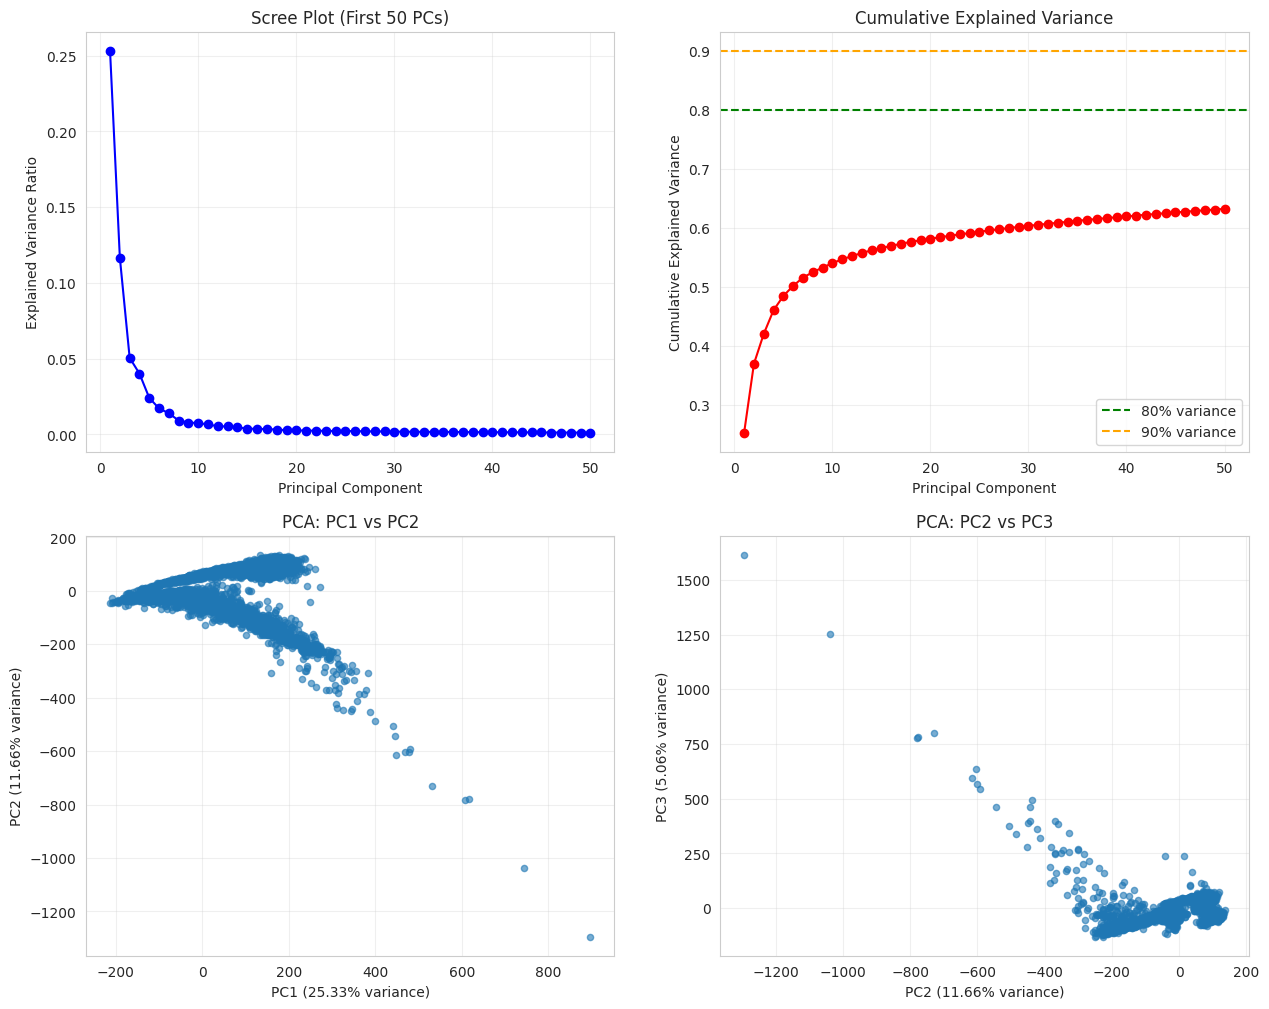

In [6]:
# Prepare data for PCA
# Use log-transformed, standardized data
tpm_log = np.log10(tpm_df + 1).T  # Transpose: samples x genes 
scaler = StandardScaler()
tpm_scaled = scaler.fit_transform(tpm_log)

# Perform PCA
pca = PCA()
pca_result_original_log = pca.fit_transform(tpm_scaled)

# Plot explained variance
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Scree plot
n_components_plot = min(50, len(pca.explained_variance_ratio_))
axes[0, 0].plot(range(1, n_components_plot + 1), 
                pca.explained_variance_ratio_[:n_components_plot], 'bo-')
axes[0, 0].set_xlabel('Principal Component')
axes[0, 0].set_ylabel('Explained Variance Ratio')
axes[0, 0].set_title('Scree Plot (First 50 PCs)')
axes[0, 0].grid(True, alpha=0.3)

# Cumulative explained variance
cumulative_var = np.cumsum(pca.explained_variance_ratio_)
axes[0, 1].plot(range(1, n_components_plot + 1), 
                cumulative_var[:n_components_plot], 'ro-')
axes[0, 1].set_xlabel('Principal Component')
axes[0, 1].set_ylabel('Cumulative Explained Variance')
axes[0, 1].set_title('Cumulative Explained Variance')
axes[0, 1].axhline(0.8, color='green', linestyle='--', label='80% variance')
axes[0, 1].axhline(0.9, color='orange', linestyle='--', label='90% variance')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 2. PCA plot (PC1 vs PC2)
scatter = axes[1, 0].scatter(pca_result_original_log[:, 0], pca_result_original_log[:, 1], alpha=0.6, s=20)
axes[1, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
axes[1, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
axes[1, 0].set_title('PCA: PC1 vs PC2')
axes[1, 0].grid(True, alpha=0.3)

# 3. PCA plot (PC2 vs PC3)
scatter = axes[1, 1].scatter(pca_result_original_log[:, 1], pca_result_original_log[:, 2], alpha=0.6, s=20)
axes[1, 1].set_xlabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
axes[1, 1].set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.2f}% variance)')
axes[1, 1].set_title('PCA: PC2 vs PC3')
axes[1, 1].grid(True, alpha=0.3)


print(f"First 10 PCs explain {cumulative_var[9]*100:.2f}% of variance")
print(f"First 50 PCs explain {cumulative_var[49]*100:.2f}% of variance")
print(f"Number of PCs to explain 80% variance: {np.argmax(cumulative_var >= 0.8) + 1}")
print(f"Number of PCs to explain 90% variance: {np.argmax(cumulative_var >= 0.9) + 1}")


### Filtered + log10

First 10 PCs explain 77.84% of variance
First 50 PCs explain 85.81% of variance
Number of PCs to explain 80% variance: 14
Number of PCs to explain 90% variance: 273


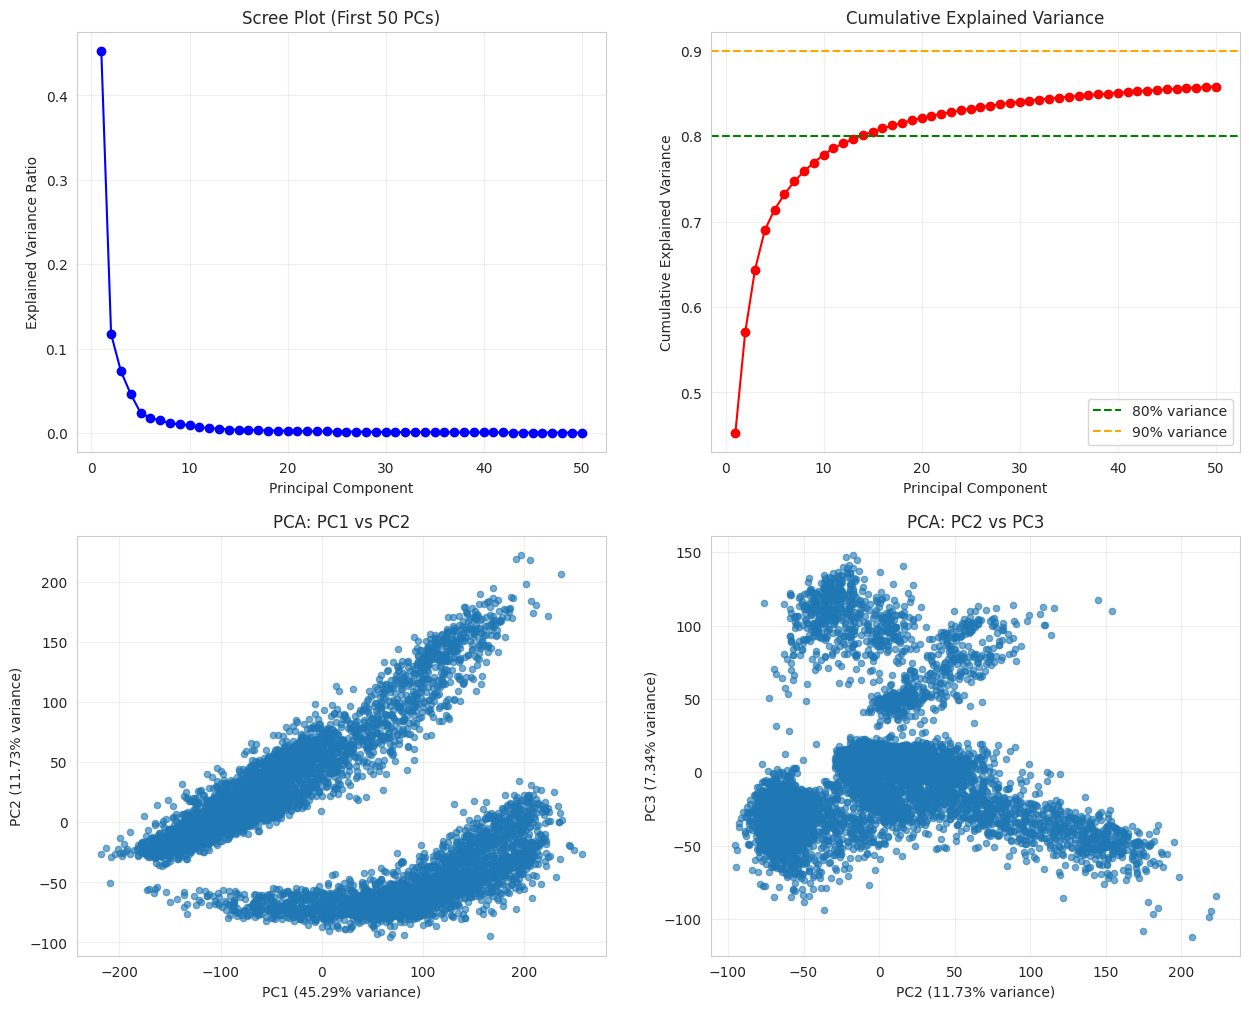

In [7]:
# Prepare data for PCA
# Use log-transformed, standardized data
tpm_log = np.log10(tpm_df_filtered + 1).T  # Transpose: samples x genes 
scaler = StandardScaler()
tpm_scaled = scaler.fit_transform(tpm_log)

# Perform PCA
pca = PCA()
pca_result_filtered_log = pca.fit_transform(tpm_scaled)

# Plot explained variance
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Scree plot
n_components_plot = min(50, len(pca.explained_variance_ratio_))
axes[0, 0].plot(range(1, n_components_plot + 1), 
                pca.explained_variance_ratio_[:n_components_plot], 'bo-')
axes[0, 0].set_xlabel('Principal Component')
axes[0, 0].set_ylabel('Explained Variance Ratio')
axes[0, 0].set_title('Scree Plot (First 50 PCs)')
axes[0, 0].grid(True, alpha=0.3)

# Cumulative explained variance
cumulative_var = np.cumsum(pca.explained_variance_ratio_)
axes[0, 1].plot(range(1, n_components_plot + 1), 
                cumulative_var[:n_components_plot], 'ro-')
axes[0, 1].set_xlabel('Principal Component')
axes[0, 1].set_ylabel('Cumulative Explained Variance')
axes[0, 1].set_title('Cumulative Explained Variance')
axes[0, 1].axhline(0.8, color='green', linestyle='--', label='80% variance')
axes[0, 1].axhline(0.9, color='orange', linestyle='--', label='90% variance')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 2. PCA plot (PC1 vs PC2)
scatter = axes[1, 0].scatter(pca_result_filtered_log[:, 0], pca_result_filtered_log[:, 1], alpha=0.6, s=20)
axes[1, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
axes[1, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
axes[1, 0].set_title('PCA: PC1 vs PC2')
axes[1, 0].grid(True, alpha=0.3)

# 3. PCA plot (PC2 vs PC3)
scatter = axes[1, 1].scatter(pca_result_filtered_log[:, 1], pca_result_filtered_log[:, 2], alpha=0.6, s=20)
axes[1, 1].set_xlabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
axes[1, 1].set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.2f}% variance)')
axes[1, 1].set_title('PCA: PC2 vs PC3')
axes[1, 1].grid(True, alpha=0.3)


print(f"First 10 PCs explain {cumulative_var[9]*100:.2f}% of variance")
print(f"First 50 PCs explain {cumulative_var[49]*100:.2f}% of variance")
print(f"Number of PCs to explain 80% variance: {np.argmax(cumulative_var >= 0.8) + 1}")
print(f"Number of PCs to explain 90% variance: {np.argmax(cumulative_var >= 0.9) + 1}")


## 5. PCA Colored by Covariates


In [9]:
covariates_df.columns


Index(['participant_id', 'disease', 'estimated_sex', 'astrocyte',
       'cohort_tissue', 'endothelial_cell', 'excitatory_neuron',
       'inhibitory_neuron', 'microglia', 'oligodendrocyte',
       ...
       'picard_rnaseq_pct_correct_strand_reads',
       'picard_rnaseq_median_cv_coverage', 'picard_rnaseq_median_5prime_bias',
       'picard_rnaseq_median_3prime_bias',
       'picard_rnaseq_median_5prime_to_3prime_bias', 'picard_rnaseq_sample',
       'picard_rnaseq_library', 'picard_rnaseq_read_group',
       'picard_rnaseq_pf_not_aligned_bases', 'cohort'],
      dtype='object', length=202)

### Original 

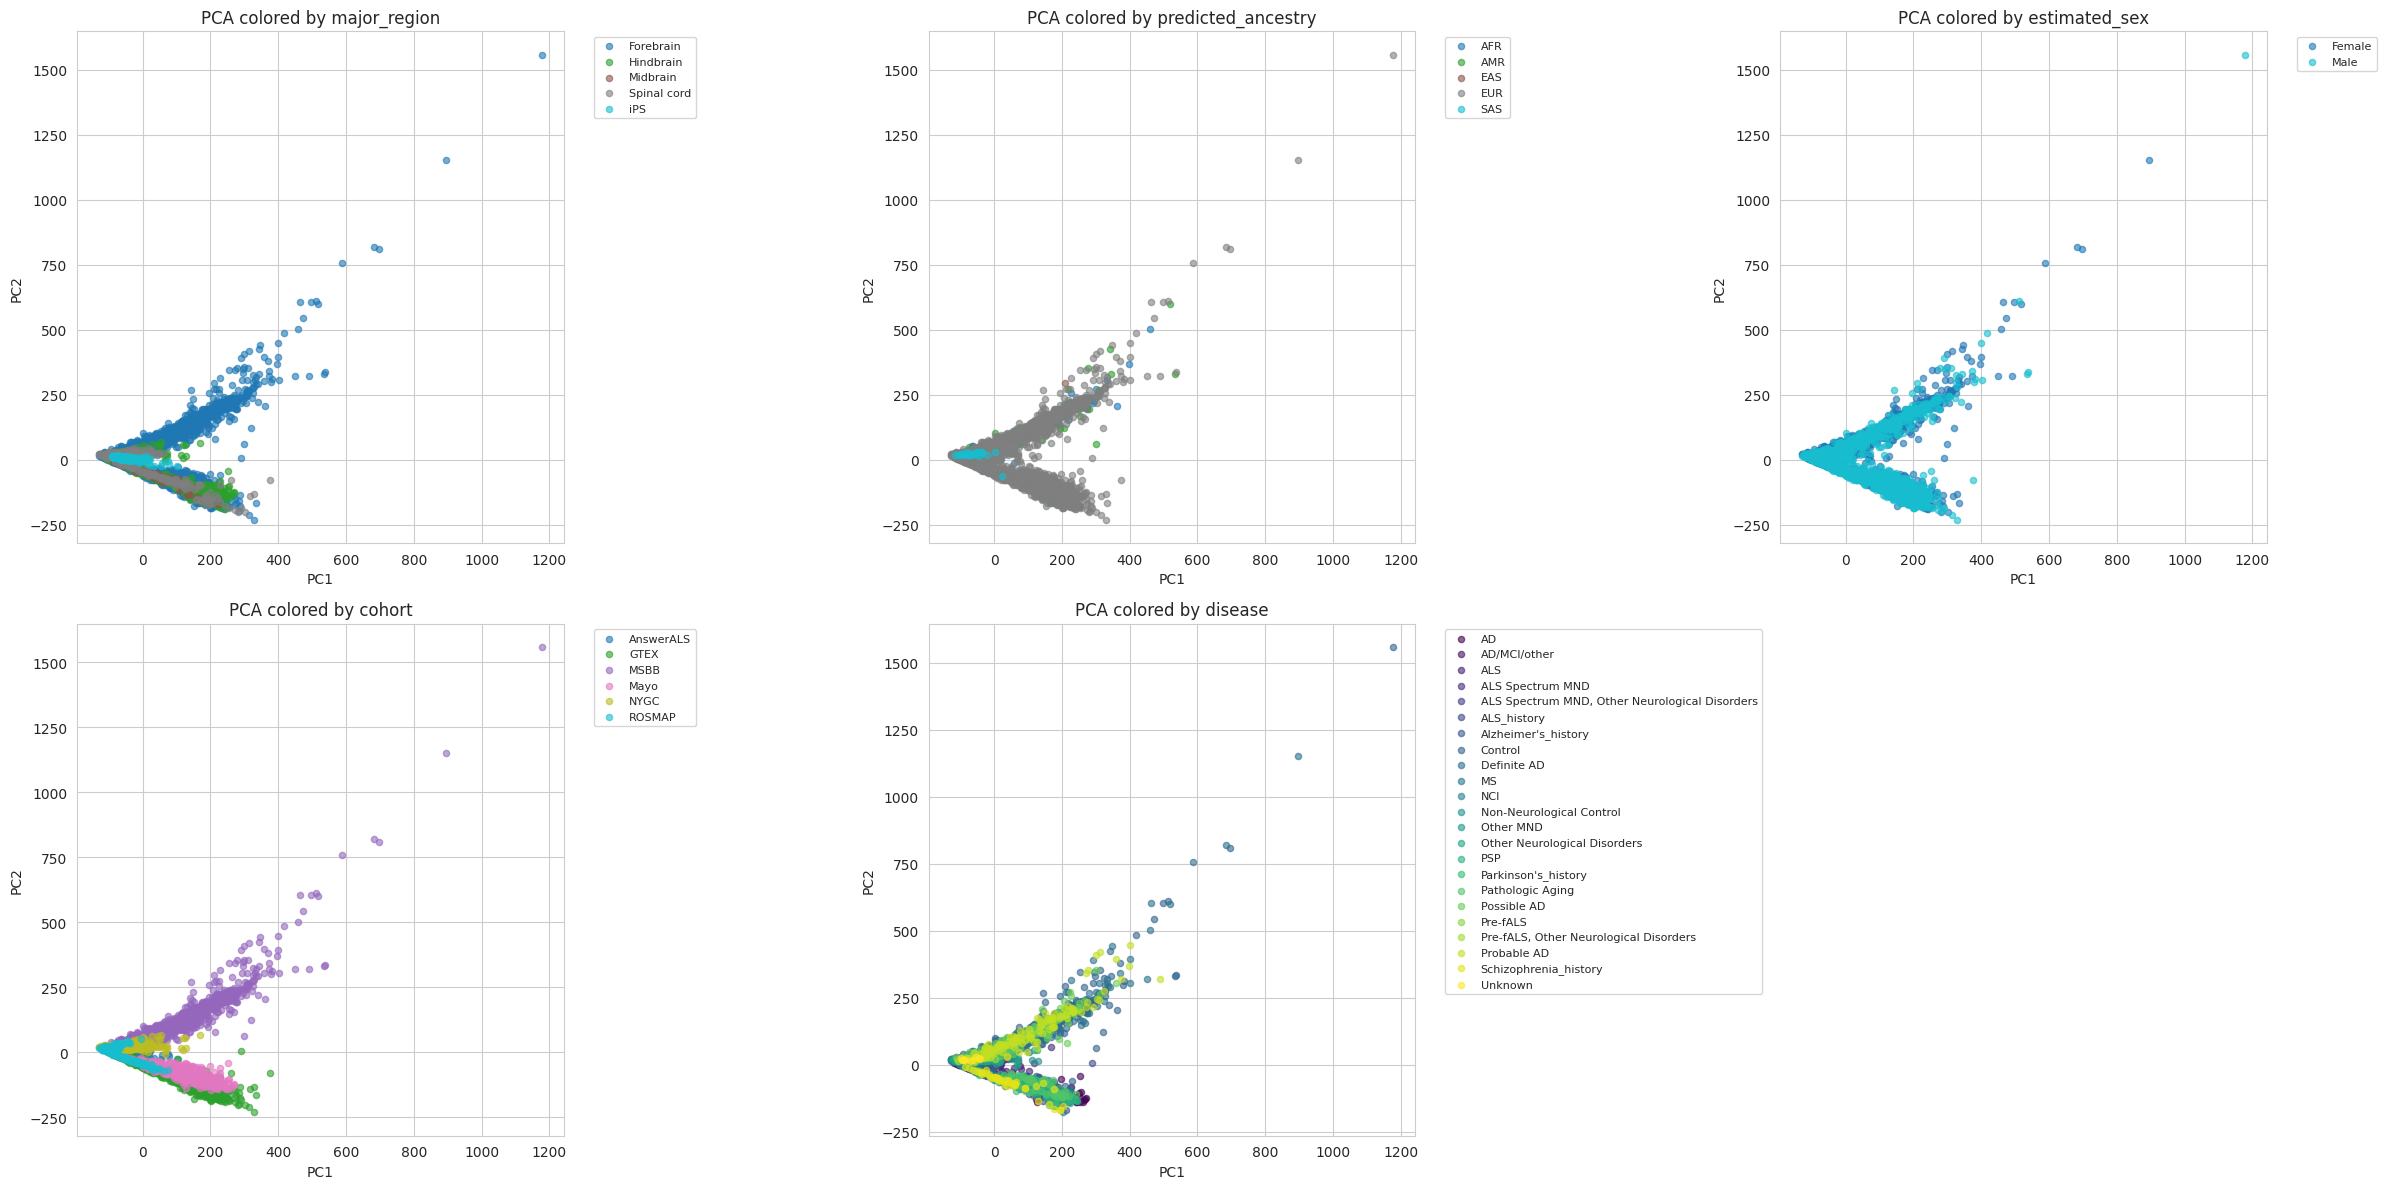

In [18]:
# Plot PCA colored by different covariates
color_cols = ['major_region', 'predicted_ancestry', 'estimated_sex', 'cohort' ,'disease']

n_plots = 5
fig, axes = plt.subplots(2, 3, figsize=(24, 12))
axes = axes.flatten()

plot_idx = 0

# Plot covariates (all are categorical)
for col in color_cols:
    # Get unique categories
    cat = pd.Categorical(covariates_df[col])
    unique_cats = cat.categories
    n_cats = len(unique_cats)
    
    # Use a colormap that can handle many categories
    if n_cats <= 10:
        cmap = plt.cm.tab10
    elif n_cats <= 20:
        cmap = plt.cm.tab20
    else:
        # For many categories, use a continuous colormap
        cmap = plt.cm.viridis
    
    # Normalize index to [0, 1] for colormap
    get_color = lambda i: cmap(i / max(n_cats - 1, 1) if n_cats > 1 else 0)
    
    # Plot each category separately to create legend
    for i, category in enumerate(unique_cats):
        mask = covariates_df[col] == category
        color = get_color(i)
        axes[plot_idx].scatter(pca_result_original[mask, 0], pca_result_original[mask, 1], 
                              c=[color], label=str(category), 
                              alpha=0.6, s=20)
    
    axes[plot_idx].set_xlabel(f'PC1')
    axes[plot_idx].set_ylabel(f'PC2')
    axes[plot_idx].set_title(f'PCA colored by {col}')
    axes[plot_idx].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plot_idx += 1

# Hide unused subplots
for i in range(plot_idx, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()


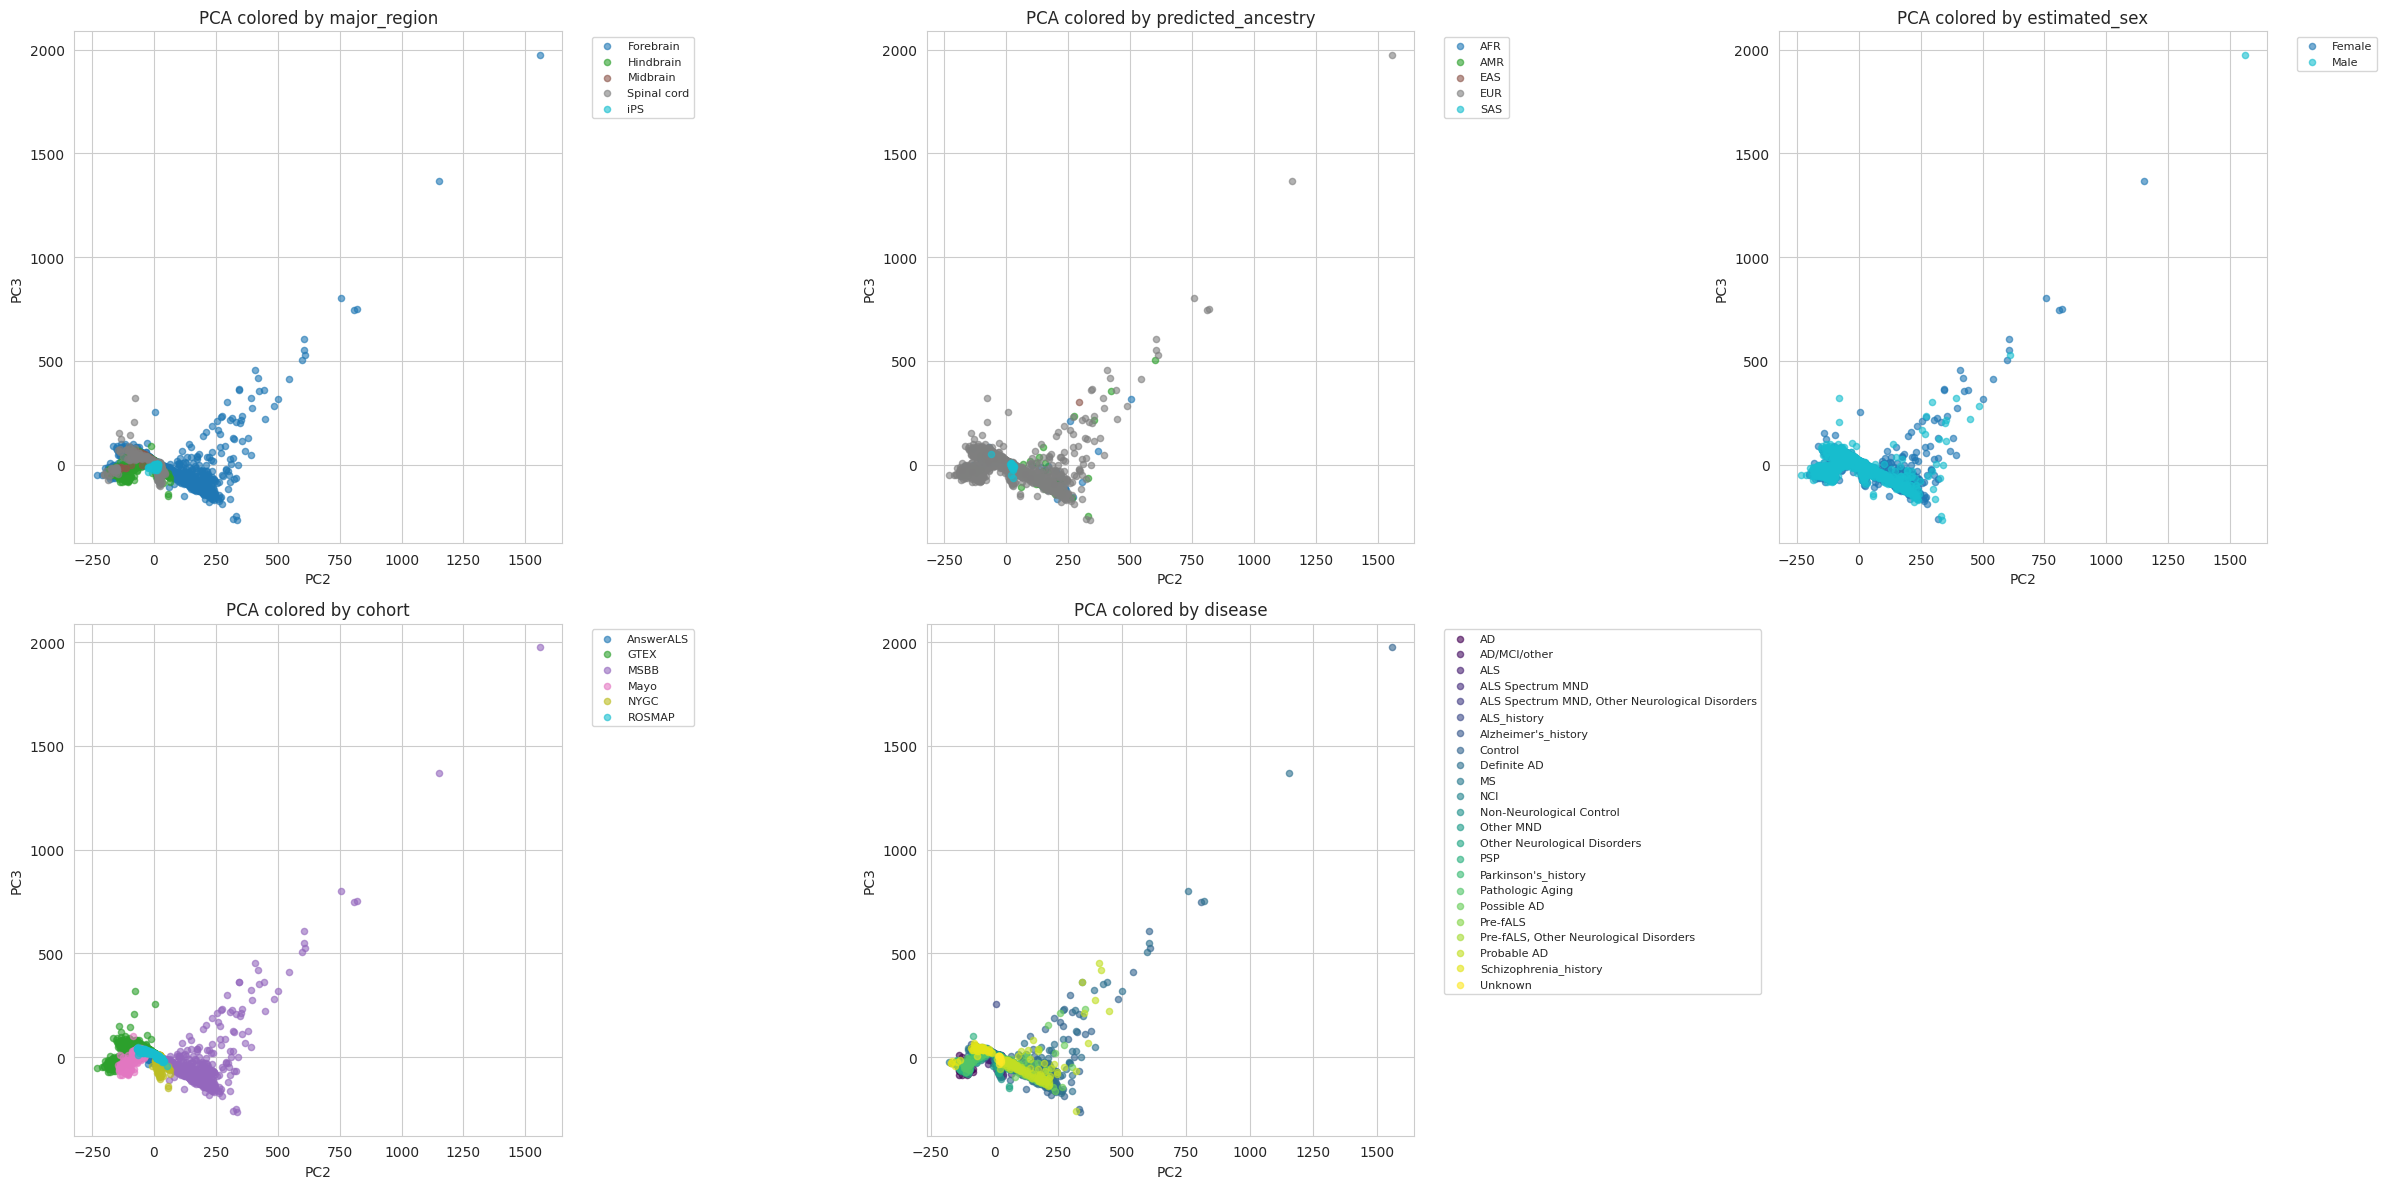

In [15]:
# Plot PCA colored by different covariates
color_cols = ['major_region', 'predicted_ancestry', 'estimated_sex', 'cohort' ,'disease']

n_plots = 5
fig, axes = plt.subplots(2, 3, figsize=(24, 12))
axes = axes.flatten()

plot_idx = 0

# Plot covariates (all are categorical)
for col in color_cols:
    # Get unique categories
    cat = pd.Categorical(covariates_df[col])
    unique_cats = cat.categories
    n_cats = len(unique_cats)
    
    # Use a colormap that can handle many categories
    if n_cats <= 10:
        cmap = plt.cm.tab10
    elif n_cats <= 20:
        cmap = plt.cm.tab20
    else:
        # For many categories, use a continuous colormap
        cmap = plt.cm.viridis
    
    # Normalize index to [0, 1] for colormap
    get_color = lambda i: cmap(i / max(n_cats - 1, 1) if n_cats > 1 else 0)
    
    # Plot each category separately to create legend
    for i, category in enumerate(unique_cats):
        mask = covariates_df[col] == category
        color = get_color(i)
        axes[plot_idx].scatter(pca_result_original[mask, 1], pca_result_original[mask, 2], 
                              c=[color], label=str(category), 
                              alpha=0.6, s=20)
    
    axes[plot_idx].set_xlabel(f'PC2')
    axes[plot_idx].set_ylabel(f'PC3')
    axes[plot_idx].set_title(f'PCA colored by {col}')
    axes[plot_idx].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plot_idx += 1

# Hide unused subplots
for i in range(plot_idx, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()


### Original + log10

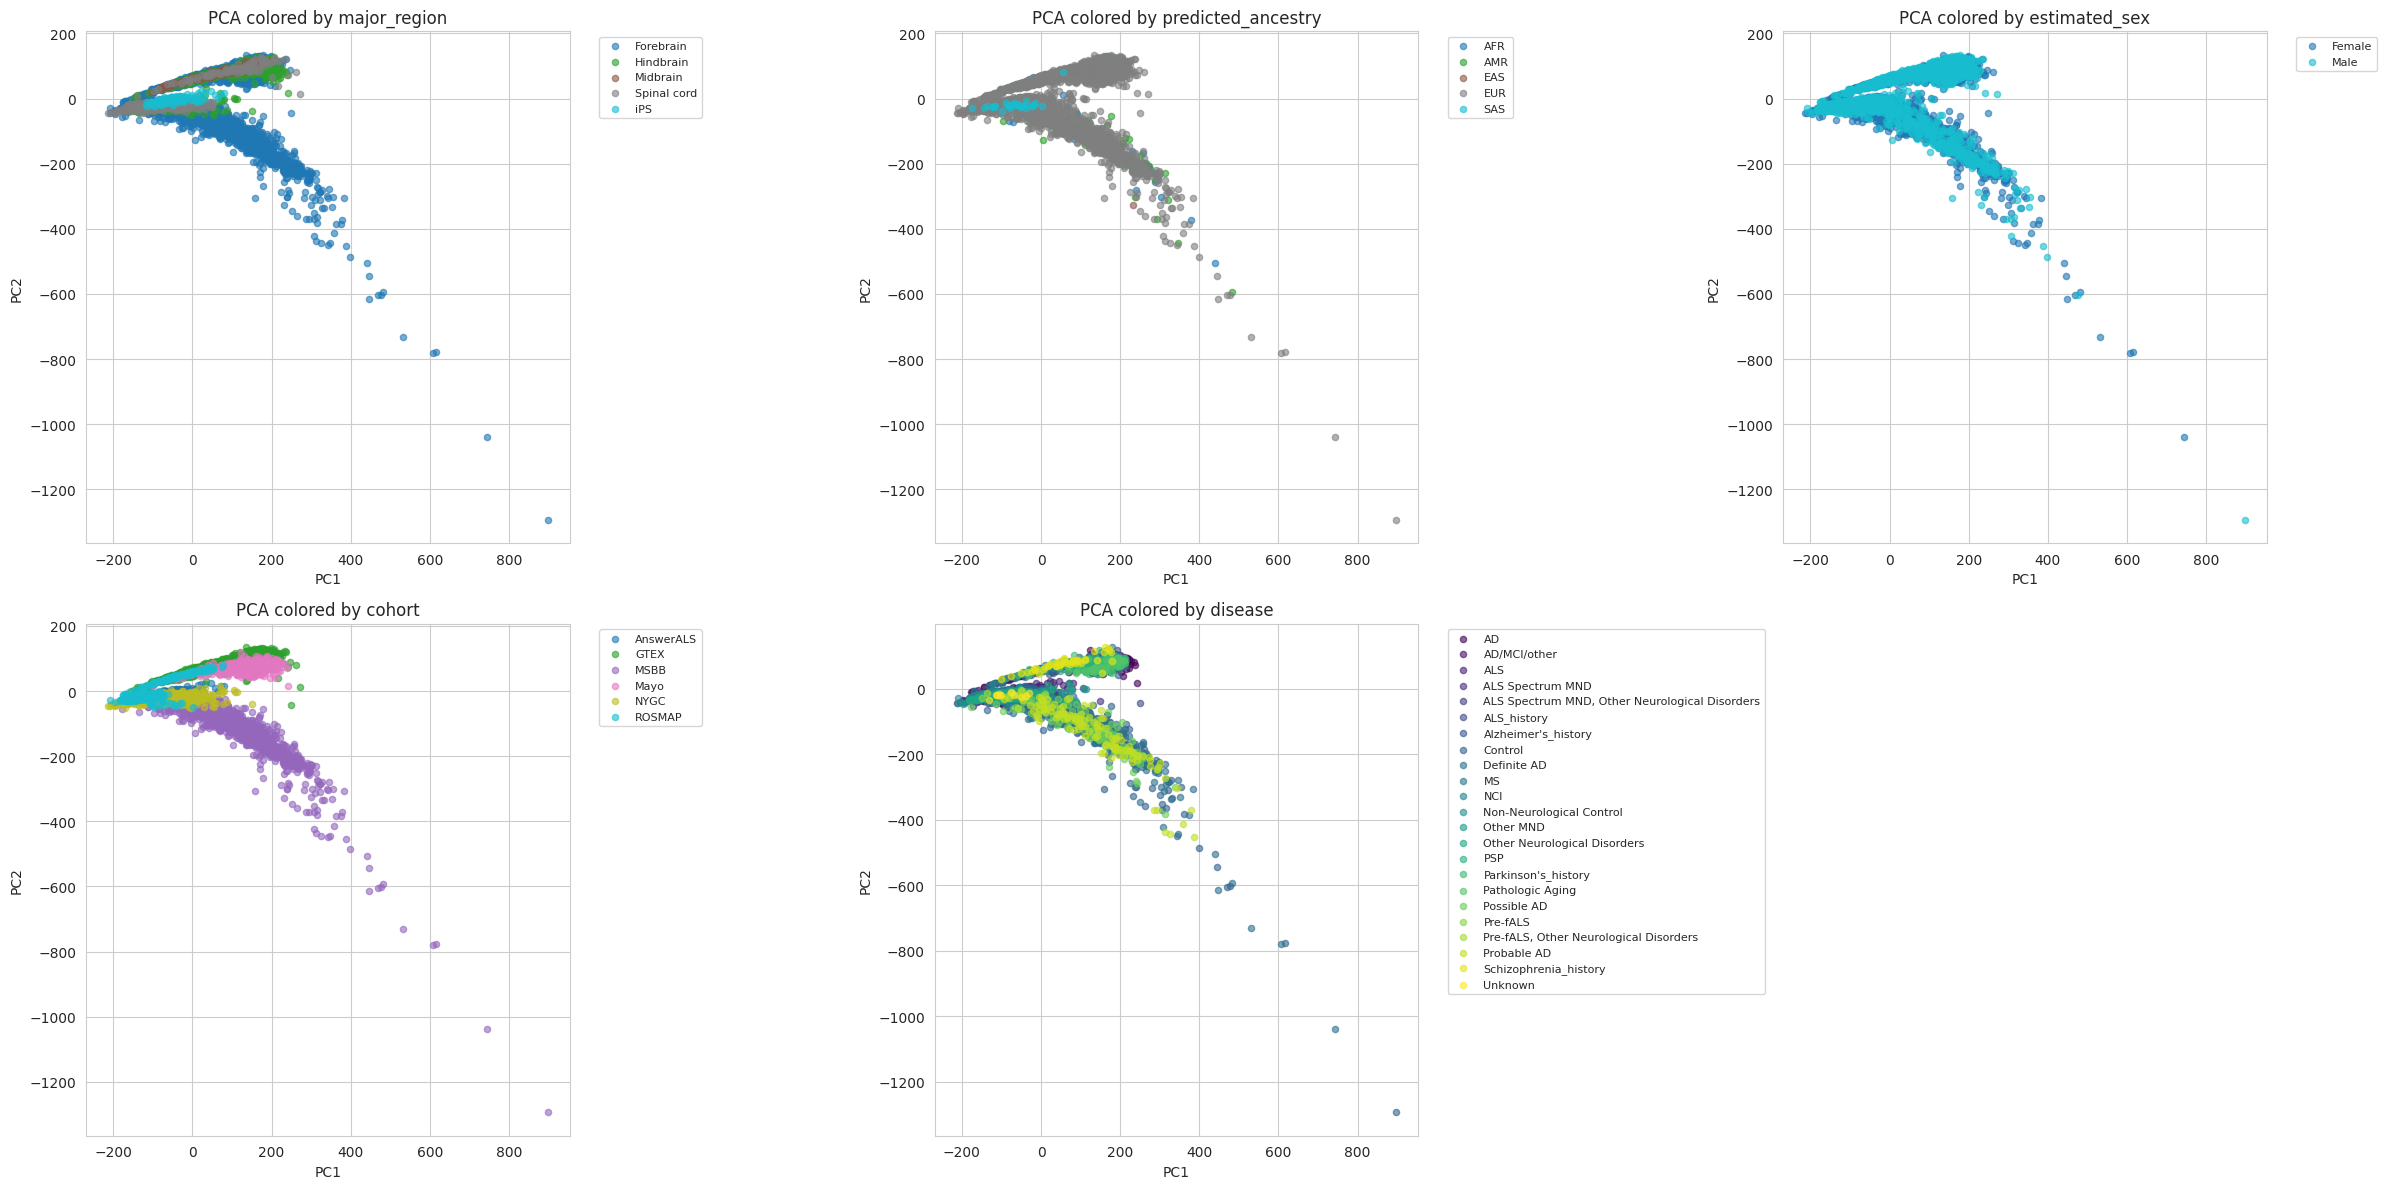

In [19]:
# Plot PCA colored by different covariates
color_cols = ['major_region', 'predicted_ancestry', 'estimated_sex', 'cohort' ,'disease']

n_plots = 5
fig, axes = plt.subplots(2, 3, figsize=(24, 12))
axes = axes.flatten()

plot_idx = 0

# Plot covariates (all are categorical)
for col in color_cols:
    # Get unique categories
    cat = pd.Categorical(covariates_df[col])
    unique_cats = cat.categories
    n_cats = len(unique_cats)
    
    # Use a colormap that can handle many categories
    if n_cats <= 10:
        cmap = plt.cm.tab10
    elif n_cats <= 20:
        cmap = plt.cm.tab20
    else:
        # For many categories, use a continuous colormap
        cmap = plt.cm.viridis
    
    # Normalize index to [0, 1] for colormap
    get_color = lambda i: cmap(i / max(n_cats - 1, 1) if n_cats > 1 else 0)
    
    # Plot each category separately to create legend
    for i, category in enumerate(unique_cats):
        mask = covariates_df[col] == category
        color = get_color(i)
        axes[plot_idx].scatter(pca_result_original_log[mask, 0], pca_result_original_log[mask, 1], 
                              c=[color], label=str(category), 
                              alpha=0.6, s=20)
    
    axes[plot_idx].set_xlabel(f'PC1')
    axes[plot_idx].set_ylabel(f'PC2')
    axes[plot_idx].set_title(f'PCA colored by {col}')
    axes[plot_idx].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plot_idx += 1

# Hide unused subplots
for i in range(plot_idx, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()


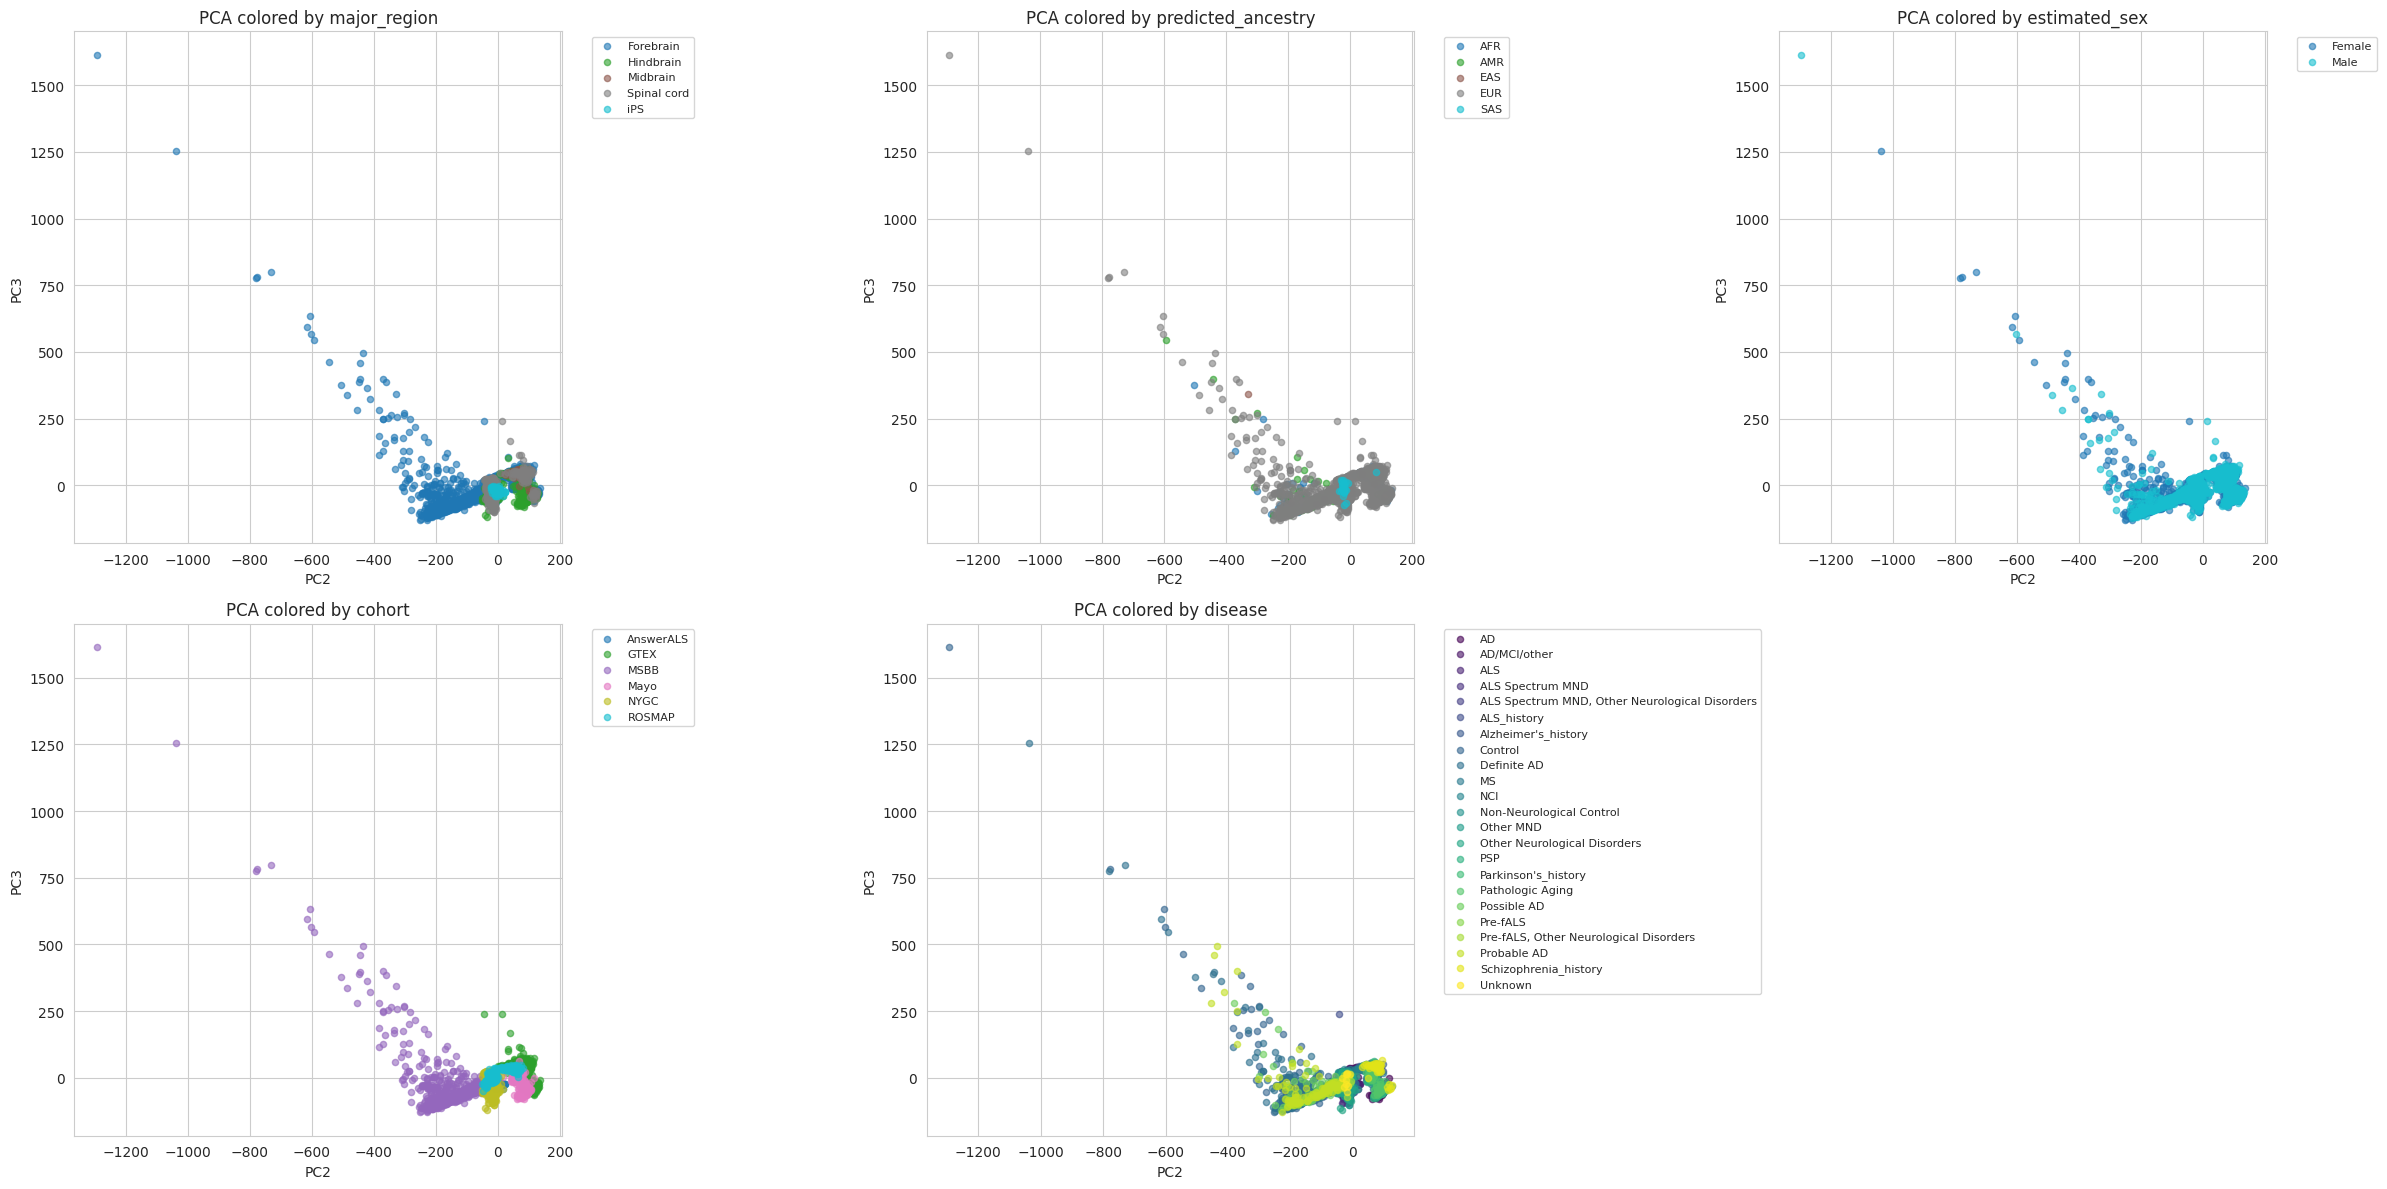

In [16]:
# Plot PCA colored by different covariates
color_cols = ['major_region', 'predicted_ancestry', 'estimated_sex', 'cohort' ,'disease']

n_plots = 5
fig, axes = plt.subplots(2, 3, figsize=(24, 12))
axes = axes.flatten()

plot_idx = 0

# Plot covariates (all are categorical)
for col in color_cols:
    # Get unique categories
    cat = pd.Categorical(covariates_df[col])
    unique_cats = cat.categories
    n_cats = len(unique_cats)
    
    # Use a colormap that can handle many categories
    if n_cats <= 10:
        cmap = plt.cm.tab10
    elif n_cats <= 20:
        cmap = plt.cm.tab20
    else:
        # For many categories, use a continuous colormap
        cmap = plt.cm.viridis
    
    # Normalize index to [0, 1] for colormap
    get_color = lambda i: cmap(i / max(n_cats - 1, 1) if n_cats > 1 else 0)
    
    # Plot each category separately to create legend
    for i, category in enumerate(unique_cats):
        mask = covariates_df[col] == category
        color = get_color(i)
        axes[plot_idx].scatter(pca_result_original_log[mask, 1], pca_result_original_log[mask, 2], 
                              c=[color], label=str(category), 
                              alpha=0.6, s=20)
    
    axes[plot_idx].set_xlabel(f'PC2')
    axes[plot_idx].set_ylabel(f'PC3')
    axes[plot_idx].set_title(f'PCA colored by {col}')
    axes[plot_idx].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plot_idx += 1

# Hide unused subplots
for i in range(plot_idx, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()


### Filtered

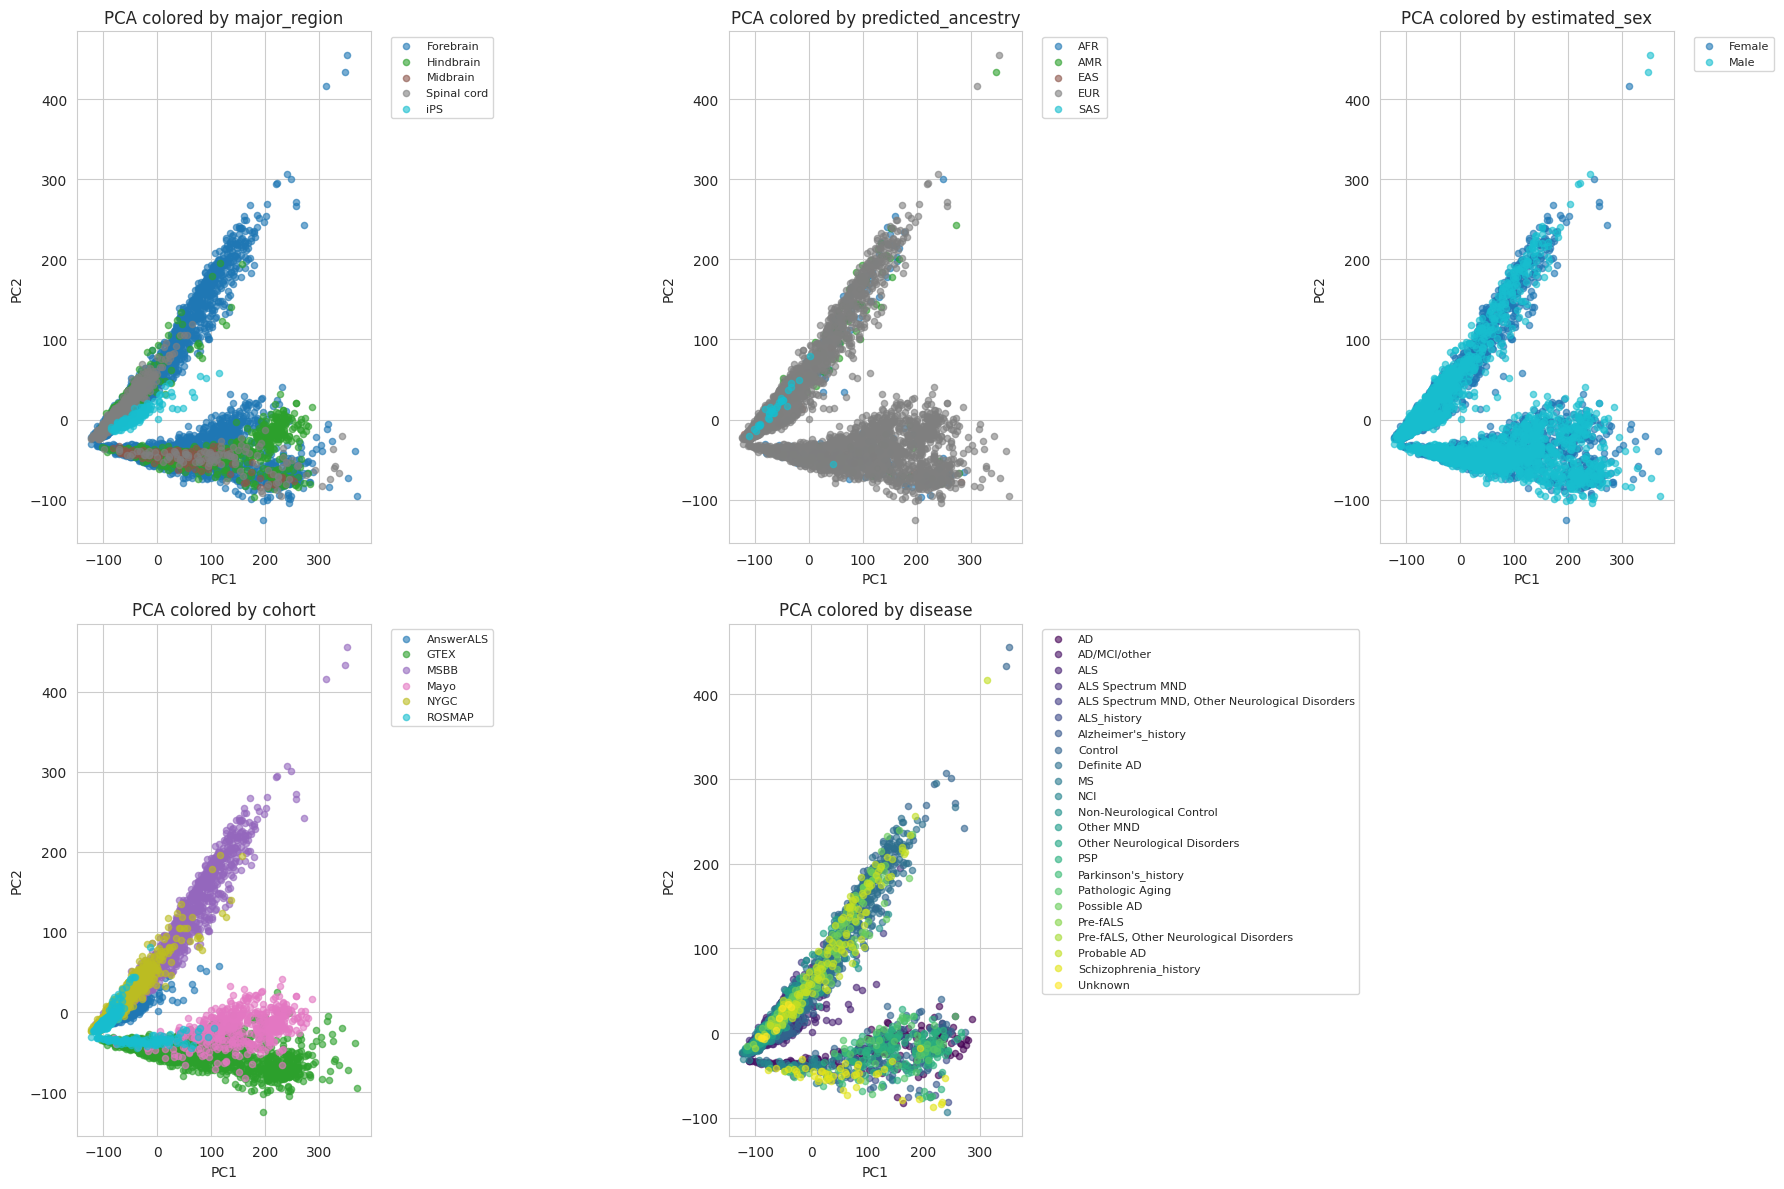

In [20]:
# Plot PCA colored by different covariates
color_cols = ['major_region', 'predicted_ancestry', 'estimated_sex', 'cohort' ,'disease']

n_plots = 5
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

plot_idx = 0

# Plot covariates (all are categorical)
for col in color_cols:
    # Get unique categories
    cat = pd.Categorical(covariates_df[col])
    unique_cats = cat.categories
    n_cats = len(unique_cats)
    
    # Use a colormap that can handle many categories
    if n_cats <= 10:
        cmap = plt.cm.tab10
    elif n_cats <= 20:
        cmap = plt.cm.tab20
    else:
        # For many categories, use a continuous colormap
        cmap = plt.cm.viridis
    
    # Normalize index to [0, 1] for colormap
    get_color = lambda i: cmap(i / max(n_cats - 1, 1) if n_cats > 1 else 0)
    
    # Plot each category separately to create legend
    for i, category in enumerate(unique_cats):
        mask = covariates_df[col] == category
        color = get_color(i)
        axes[plot_idx].scatter(pca_result_filtered[mask, 0], pca_result_filtered[mask, 1], 
                              c=[color], label=str(category), 
                              alpha=0.6, s=20)
    
    axes[plot_idx].set_xlabel(f'PC1')
    axes[plot_idx].set_ylabel(f'PC2')
    axes[plot_idx].set_title(f'PCA colored by {col}')
    axes[plot_idx].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plot_idx += 1

# Hide unused subplots
for i in range(plot_idx, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()


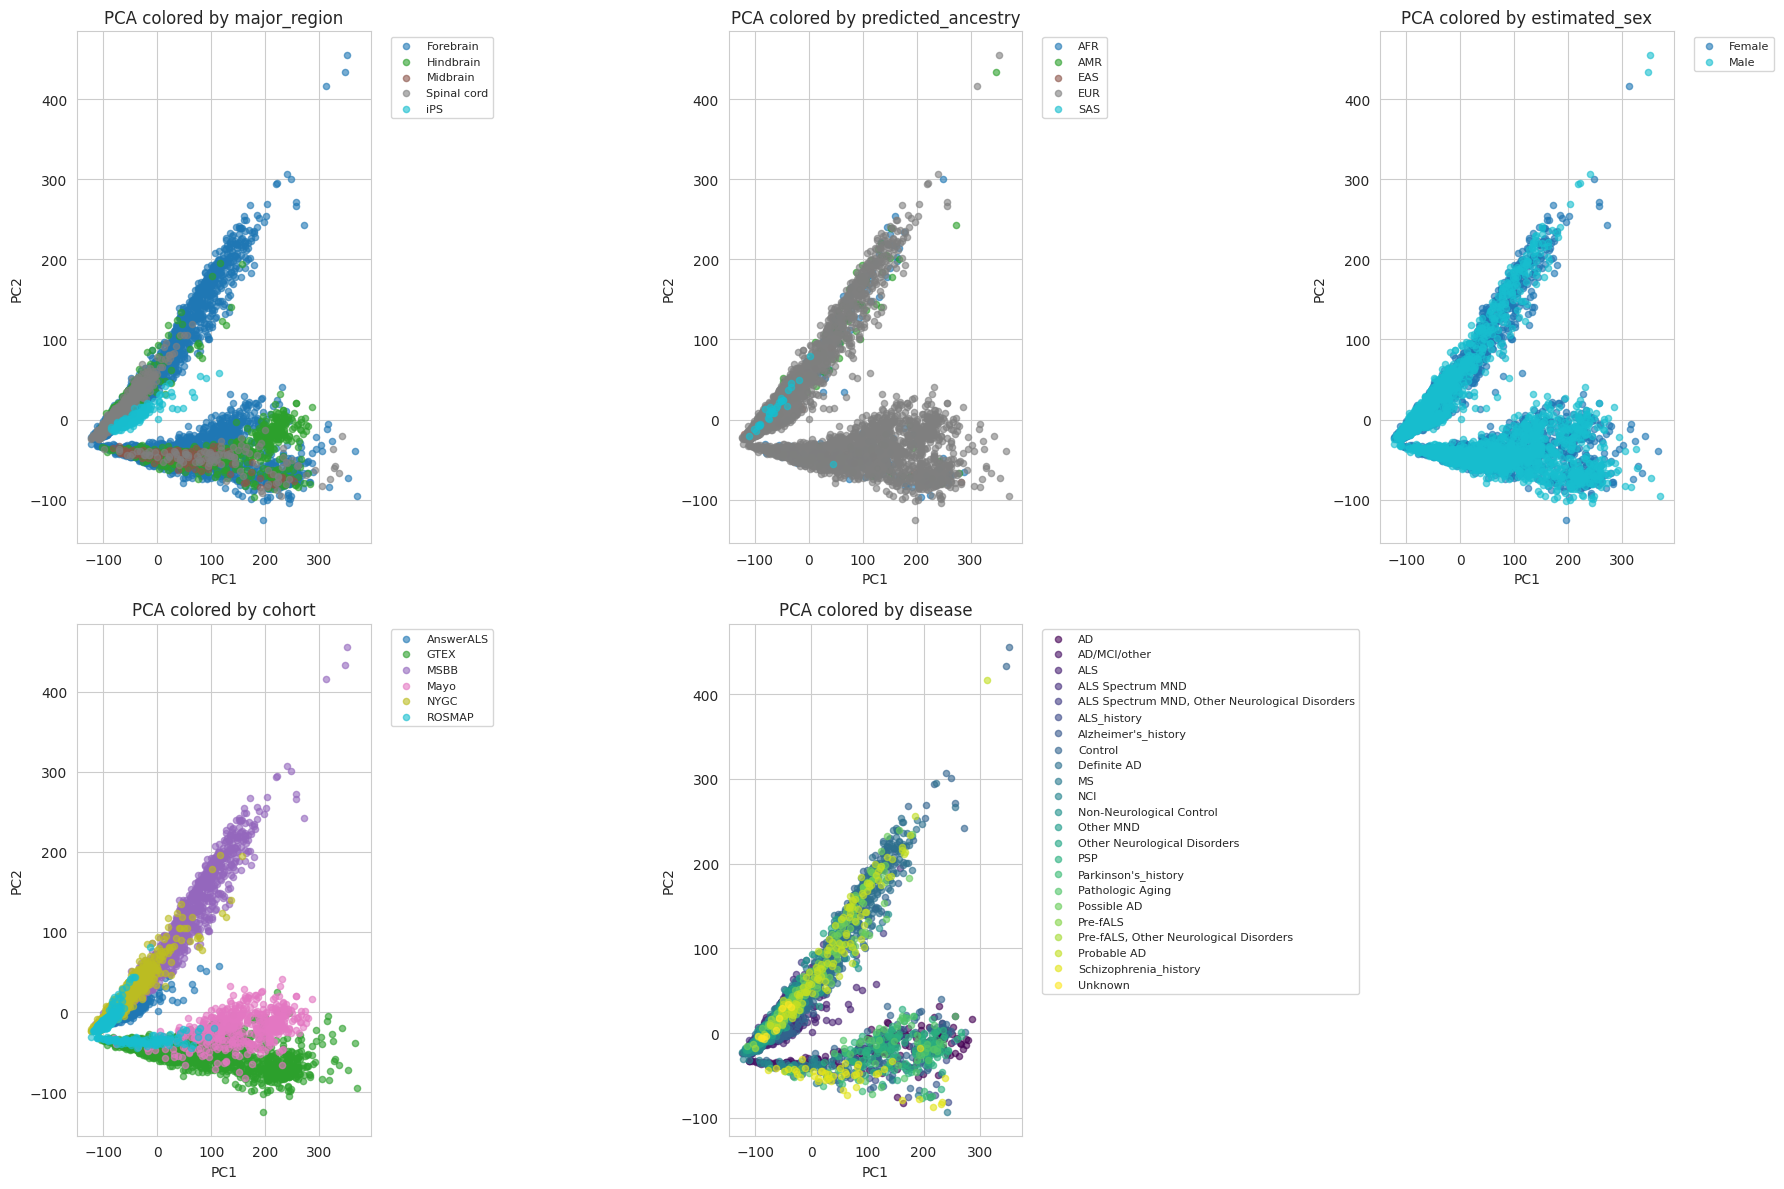

In [ ]:
# Plot PCA colored by different covariates
color_cols = ['major_region', 'predicted_ancestry', 'estimated_sex', 'cohort' ,'disease']

n_plots = 5
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

plot_idx = 0

# Plot covariates (all are categorical)
for col in color_cols:
    # Get unique categories
    cat = pd.Categorical(covariates_df[col])
    unique_cats = cat.categories
    n_cats = len(unique_cats)
    
    # Use a colormap that can handle many categories
    if n_cats <= 10:
        cmap = plt.cm.tab10
    elif n_cats <= 20:
        cmap = plt.cm.tab20
    else:
        # For many categories, use a continuous colormap
        cmap = plt.cm.viridis
    
    # Normalize index to [0, 1] for colormap
    get_color = lambda i: cmap(i / max(n_cats - 1, 1) if n_cats > 1 else 0)
    
    # Plot each category separately to create legend
    for i, category in enumerate(unique_cats):
        mask = covariates_df[col] == category
        color = get_color(i)
        axes[plot_idx].scatter(pca_result_filtered[mask, 1], pca_result_filtered[mask, 2], 
                              c=[color], label=str(category), 
                              alpha=0.6, s=20)
    
    axes[plot_idx].set_xlabel(f'PC2')
    axes[plot_idx].set_ylabel(f'PC3')
    axes[plot_idx].set_title(f'PCA colored by {col}')
    axes[plot_idx].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plot_idx += 1

# Hide unused subplots
for i in range(plot_idx, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()


### Filtered + log10

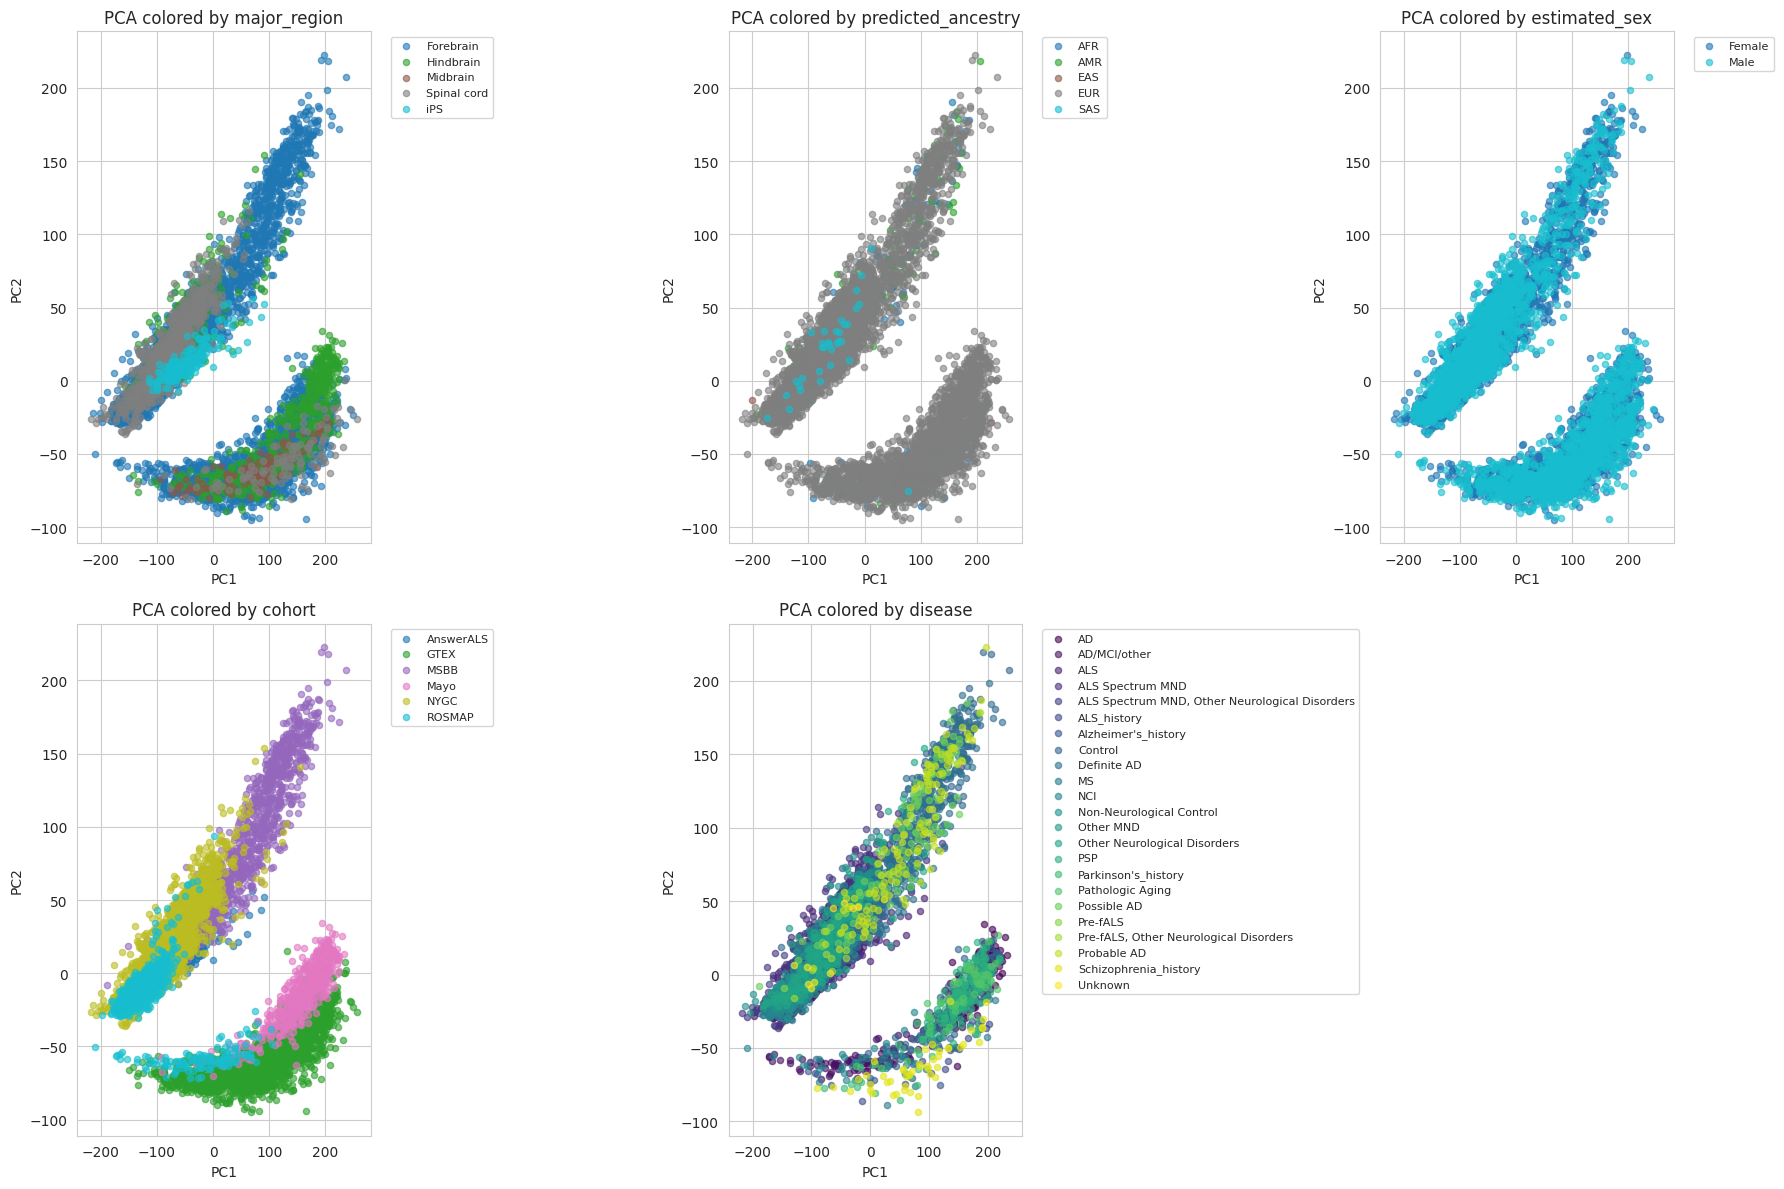

In [21]:
# Plot PCA colored by different covariates
color_cols = ['major_region', 'predicted_ancestry', 'estimated_sex', 'cohort' ,'disease']

n_plots = 5
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

plot_idx = 0

# Plot covariates (all are categorical)
for col in color_cols:
    # Get unique categories
    cat = pd.Categorical(covariates_df[col])
    unique_cats = cat.categories
    n_cats = len(unique_cats)
    
    # Use a colormap that can handle many categories
    if n_cats <= 10:
        cmap = plt.cm.tab10
    elif n_cats <= 20:
        cmap = plt.cm.tab20
    else:
        # For many categories, use a continuous colormap
        cmap = plt.cm.viridis
    
    # Normalize index to [0, 1] for colormap
    get_color = lambda i: cmap(i / max(n_cats - 1, 1) if n_cats > 1 else 0)
    
    # Plot each category separately to create legend
    for i, category in enumerate(unique_cats):
        mask = covariates_df[col] == category
        color = get_color(i)
        axes[plot_idx].scatter(pca_result_filtered_log[mask, 0], pca_result_filtered_log[mask, 1], 
                              c=[color], label=str(category), 
                              alpha=0.6, s=20)
    
    axes[plot_idx].set_xlabel(f'PC1')
    axes[plot_idx].set_ylabel(f'PC2')
    axes[plot_idx].set_title(f'PCA colored by {col}')
    axes[plot_idx].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plot_idx += 1

# Hide unused subplots
for i in range(plot_idx, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()


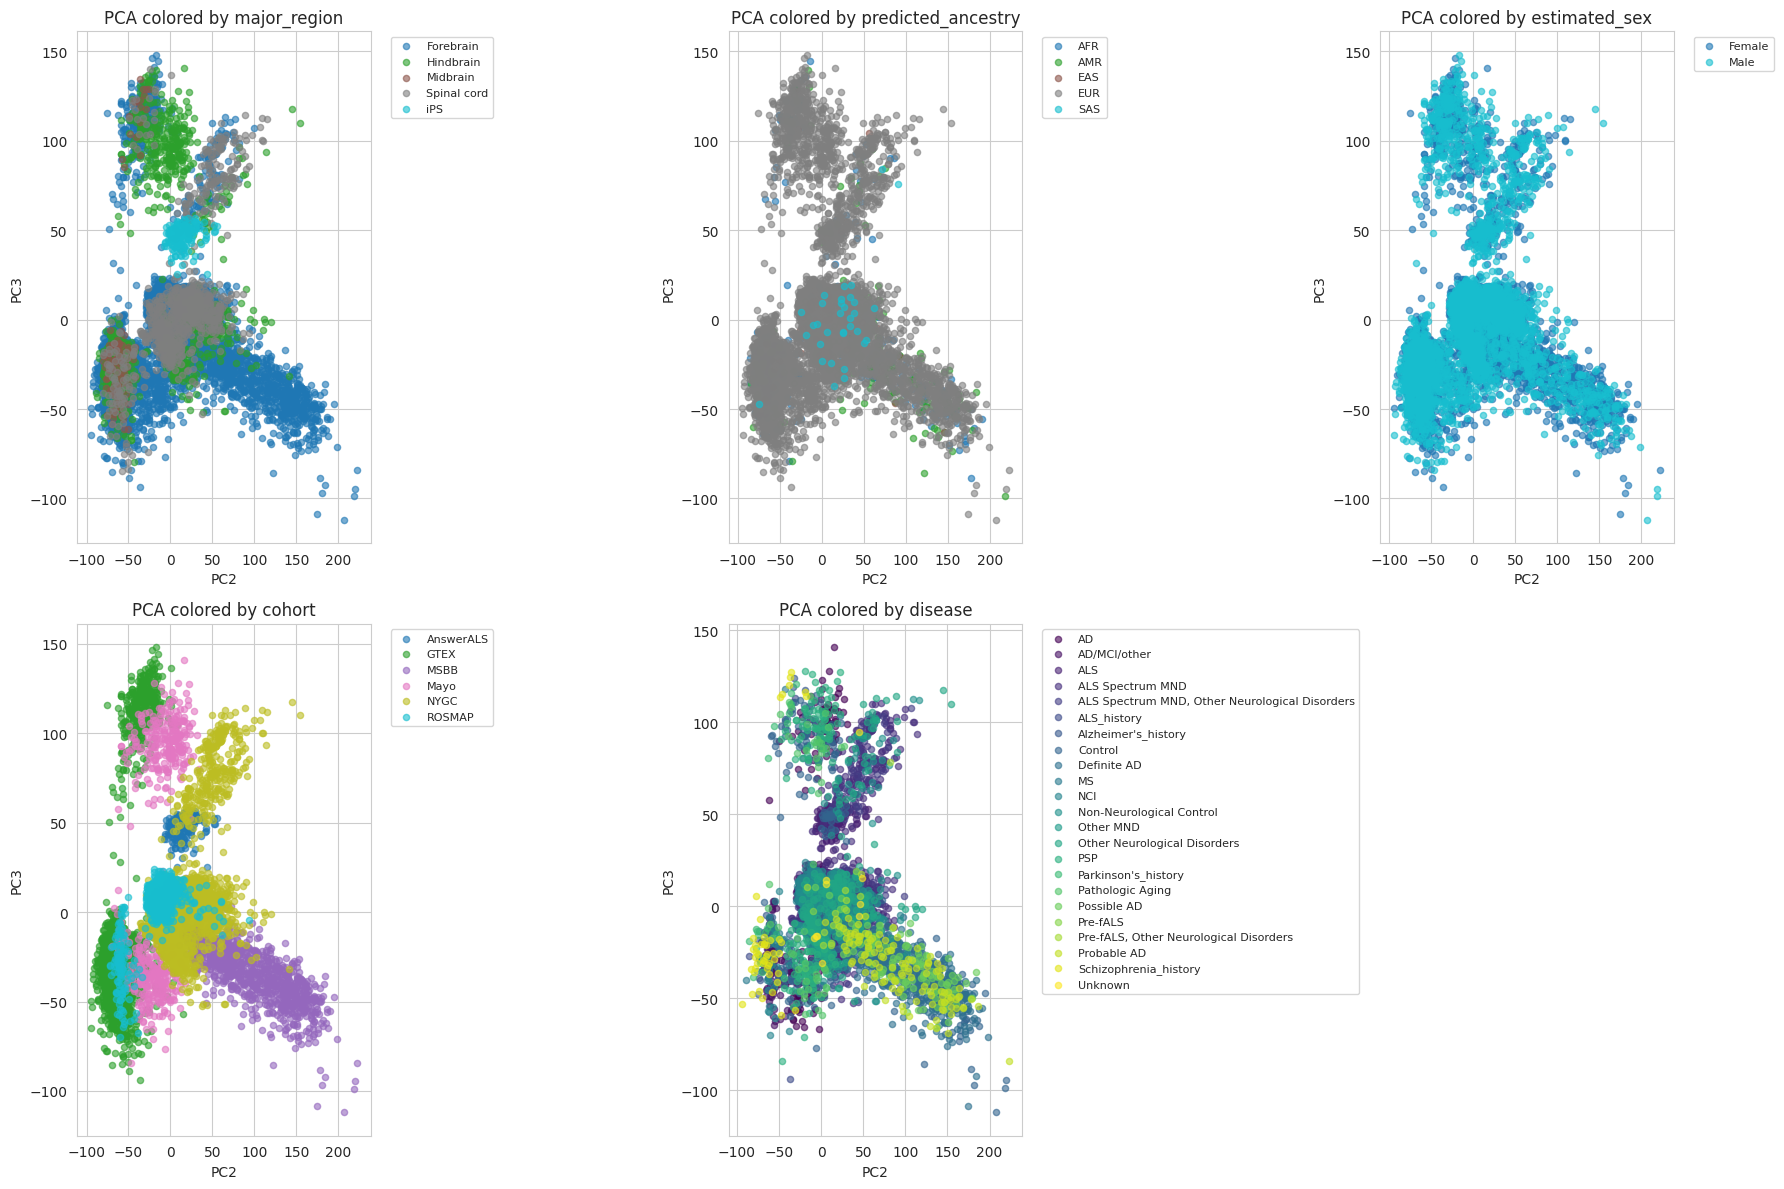

In [17]:
# Plot PCA colored by different covariates
color_cols = ['major_region', 'predicted_ancestry', 'estimated_sex', 'cohort' ,'disease']

n_plots = 5
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

plot_idx = 0

# Plot covariates (all are categorical)
for col in color_cols:
    # Get unique categories
    cat = pd.Categorical(covariates_df[col])
    unique_cats = cat.categories
    n_cats = len(unique_cats)
    
    # Use a colormap that can handle many categories
    if n_cats <= 10:
        cmap = plt.cm.tab10
    elif n_cats <= 20:
        cmap = plt.cm.tab20
    else:
        # For many categories, use a continuous colormap
        cmap = plt.cm.viridis
    
    # Normalize index to [0, 1] for colormap
    get_color = lambda i: cmap(i / max(n_cats - 1, 1) if n_cats > 1 else 0)
    
    # Plot each category separately to create legend
    for i, category in enumerate(unique_cats):
        mask = covariates_df[col] == category
        color = get_color(i)
        axes[plot_idx].scatter(pca_result_filtered_log[mask, 1], pca_result_filtered_log[mask, 2], 
                              c=[color], label=str(category), 
                              alpha=0.6, s=20)
    
    axes[plot_idx].set_xlabel(f'PC2')
    axes[plot_idx].set_ylabel(f'PC3')
    axes[plot_idx].set_title(f'PCA colored by {col}')
    axes[plot_idx].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plot_idx += 1

# Hide unused subplots
for i in range(plot_idx, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
"""
Script to generate side-by-side comparison figures for presentation.
This creates publication-quality comparison plots showing all transformations together.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style for presentation
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 10

# Create output directory
import os
os.makedirs('presentation_figures', exist_ok=True)

# Load data
print("Loading data...")
tpm_file = "/gpfs/commons/groups/knowles_lab/vmazeeva/BigBrain/Processed/Train/tpm.tsv"
covariates_file = "/gpfs/commons/groups/knowles_lab/vmazeeva/BigBrain/Processed/Train/covariates.tsv"

tpm_df = pd.read_csv(tpm_file, sep='\t', index_col=0)
covariates_df = pd.read_csv(covariates_file, sep='\t', index_col=0)

# Filter genes
zero_fraction = (tpm_df == 0).sum(axis=1) / tpm_df.shape[1]
tpm_df_filtered = tpm_df.loc[zero_fraction < 0.5]

print(f"Original: {tpm_df.shape[0]} genes")
print(f"Filtered: {tpm_df_filtered.shape[0]} genes")

# Prepare all transformations and compute PCA
print("\nComputing PCA for all transformations...")

transformations = {
    'Original': (tpm_df, False),
    'Filtered': (tpm_df_filtered, False),
    'Original + Log10': (tpm_df, True),
    'Filtered + Log10': (tpm_df_filtered, True)
}

pca_results = {}
pca_objects = {}
variance_stats = {}

for name, (data, use_log) in transformations.items():
    print(f"  Processing {name}...")
    tpm = data.T  # samples x genes
    
    if use_log:
        tpm = np.log10(tpm + 1)
    
    scaler = StandardScaler()
    tpm_scaled = scaler.fit_transform(tpm)
    
    pca = PCA()
    pca_result = pca.fit_transform(tpm_scaled)
    
    pca_results[name] = pca_result
    pca_objects[name] = pca
    
    # Calculate variance statistics
    cumulative_var = np.cumsum(pca.explained_variance_ratio_)
    variance_stats[name] = {
        'first_10_pc': cumulative_var[9] * 100,
        'first_50_pc': cumulative_var[49] * 100 if len(cumulative_var) > 49 else cumulative_var[-1] * 100,
        'pcs_for_80': np.argmax(cumulative_var >= 0.8) + 1,
        'pcs_for_90': np.argmax(cumulative_var >= 0.9) + 1 if np.any(cumulative_var >= 0.9) else len(cumulative_var)
    }

# 1. Variance explained comparison
print("\nGenerating variance comparison figure...")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

colors = {'Original': 'blue', 
          'Filtered': 'green',
          'Original + Log10': 'orange',
          'Filtered + Log10': 'red'}

# Scree plots (first 50 PCs)
ax = axes[0, 0]
n_components_plot = 50
for name in transformations.keys():
    pca = pca_objects[name]
    n_plot = min(n_components_plot, len(pca.explained_variance_ratio_))
    ax.plot(range(1, n_plot + 1), 
            pca.explained_variance_ratio_[:n_plot], 
            'o-', label=name, color=colors[name], alpha=0.7, linewidth=2, markersize=4)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Scree Plot: Variance Explained by Each PC')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Cumulative variance
ax = axes[0, 1]
for name in transformations.keys():
    pca = pca_objects[name]
    cumulative_var = np.cumsum(pca.explained_variance_ratio_)
    n_plot = min(n_components_plot, len(cumulative_var))
    ax.plot(range(1, n_plot + 1), 
            cumulative_var[:n_plot], 
            'o-', label=name, color=colors[name], alpha=0.7, linewidth=2, markersize=4)
ax.axhline(0.8, color='black', linestyle='--', linewidth=1, label='80% variance')
ax.axhline(0.9, color='gray', linestyle='--', linewidth=1, label='90% variance')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('Cumulative Explained Variance')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# Summary table
ax = axes[1, 0]
ax.axis('off')
table_data = []
for name in transformations.keys():
    stats = variance_stats[name]
    table_data.append([
        name,
        f"{stats['first_10_pc']:.2f}%",
        f"{stats['pcs_for_80']}",
        f"{stats['pcs_for_90']}"
    ])

table = ax.table(cellText=table_data,
                colLabels=['Transformation', '10 PCs Explain', 'PCs for 80%', 'PCs for 90%'],
                cellLoc='left',
                loc='center',
                colWidths=[0.4, 0.2, 0.2, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)
ax.set_title('Variance Compression Comparison', pad=20, fontsize=16)

# Bar chart comparing PCs needed for 80% variance
ax = axes[1, 1]
names_short = [name.split('(')[0].strip() for name in transformations.keys()]
pcs_80 = [variance_stats[name]['pcs_for_80'] for name in transformations.keys()]
bars = ax.barh(names_short, pcs_80, color=[colors[name] for name in transformations.keys()], alpha=0.7)
ax.set_xlabel('Number of PCs Needed for 80% Variance')
ax.set_title('Variance Compression Efficiency')
ax.grid(True, alpha=0.3, axis='x')
# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, pcs_80)):
    ax.text(val + max(pcs_80) * 0.02, i, f'{val}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('presentation_figures/01_variance_comparison.png', dpi=300, bbox_inches='tight')
print("  Saved: presentation_figures/01_variance_comparison.png")
plt.close()

# 2. PCA space comparison (PC1 vs PC2, uncolored)
print("\nGenerating PCA space comparison...")
print("  Processing PC1 vs PC2...")
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

for idx, (name, ax) in enumerate(zip(transformations.keys(), axes.flatten())):
    pca_result = pca_results[name]
    pca = pca_objects[name]
    
    ax.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5, s=10)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
    ax.set_title(name)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('presentation_figures/02_pca12_space_comparison.png', dpi=300, bbox_inches='tight')
print("  Saved: presentation_figures/02_pca12_space_comparison.png")
plt.close()

print("  Processing PC2 vs PC3...")
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

for idx, (name, ax) in enumerate(zip(transformations.keys(), axes.flatten())):
    pca_result = pca_results[name]
    pca = pca_objects[name]
    
    ax.scatter(pca_result[:, 1], pca_result[:, 2], alpha=0.5, s=10)
    ax.set_xlabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
    ax.set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.2f}% variance)')
    ax.set_title(name)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('presentation_figures/02_pca23_space_comparison.png', dpi=300, bbox_inches='tight')
print("  Saved: presentation_figures/02_pca23_space_comparison.png")
plt.close()

print("  Processing PC1 vs PC3...")
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

for idx, (name, ax) in enumerate(zip(transformations.keys(), axes.flatten())):
    pca_result = pca_results[name]
    pca = pca_objects[name]
    
    ax.scatter(pca_result[:, 0], pca_result[:, 2], alpha=0.5, s=10)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
    ax.set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.2f}% variance)')
    ax.set_title(name)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('presentation_figures/02_pca13_space_comparison.png', dpi=300, bbox_inches='tight')
print("  Saved: presentation_figures/02_pca13_space_comparison.png")
plt.close()



Loading data...
Original: 58929 genes
Filtered: 26240 genes

Computing PCA for all transformations...
  Processing Original...
  Processing Filtered...
  Processing Original + Log10...
  Processing Filtered + Log10...

Generating variance comparison figure...
  Saved: presentation_figures/01_variance_comparison.png

Generating PCA space comparison...
  Processing PC1 vs PC2...
  Saved: presentation_figures/02_pca12_space_comparison.png
  Processing PC2 vs PC3...
  Saved: presentation_figures/02_pca23_space_comparison.png
  Processing PC1 vs PC3...
  Saved: presentation_figures/02_pca13_space_comparison.png

Generating covariate separation comparisons...

Generating PC1 vs PC2 plots ...


TypeError: '<' not supported between instances of 'float' and 'str'

In [11]:
# 3. Covariate separation comparisons
print("\nGenerating covariate separation comparisons...")
print("\nGenerating PC1 vs PC2 plots ...")


color_cols = ['major_region', 'predicted_ancestry', 'estimated_sex', 'cohort', 'disease']

# Create consistent color mappings for each covariate (used across all PC plots)
covariate_color_mappings = {}
covariate_legends = {}

for covariate in color_cols:
    # Get categories for this covariate
    cats = covariates_df[covariate].unique()  
    n_cats = len(cats)
    
    # Choose colormap
    cmap = plt.cm.viridis
    
    # Create color mapping dictionary
    color_mapping = {}
    for i, category in enumerate(cats):
        color = cmap(i / max(n_cats - 1, 1) if n_cats > 1 else 0)
        color_mapping[category] = color
    
    covariate_color_mappings[covariate] = color_mapping
    
    # Create legend handles and labels
    legend_handles = []
    legend_labels = []
    for category in cats:
        color = color_mapping[category]
        legend_handles.append(Line2D([0], [0], marker='o', color='w', 
                                     markerfacecolor=color, markersize=12, 
                                     alpha=0.6, label=str(category)))
        legend_labels.append(str(category))
    
    covariate_legends[covariate] = (legend_handles, legend_labels)

for covariate in color_cols:
    print(f"  Processing {covariate}...")
    
    color_mapping = covariate_color_mappings[covariate]
    cats = covariates_df[covariate].unique()
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    
    for idx, (name, ax) in enumerate(zip(transformations.keys(), axes.flatten())):
        pca_result = pca_results[name]
        pca = pca_objects[name]
        
        # Plot each category using consistent color mapping
        for category in cats:
            mask = covariates_df[covariate] == category
            if mask.sum() > 0:  # Only plot if category exists
                color = color_mapping[category]
                ax.scatter(pca_result[mask, 0], pca_result[mask, 1], 
                          c=[color], 
                          alpha=0.6, s=15)
        
        ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
        ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
        ax.set_title(f'{name}')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    safe_cov_name = covariate.replace(' ', '_').replace('/', '_')
    plt.savefig(f'presentation_figures/03_{safe_cov_name}_comparison.png', dpi=300, bbox_inches='tight')
    print(f"    Saved: presentation_figures/03_{safe_cov_name}_comparison.png")
    plt.close()

# 4. PC2 vs PC3 
print("\nGenerating PC2 vs PC3 plots ...")


for covariate in color_cols:
    print(f"  Processing {covariate} (PC2 vs PC3)...")
    
    color_mapping = covariate_color_mappings[covariate]
    cats = covariates_df[covariate].unique()
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    
    for idx, (name, ax) in enumerate(zip(list(transformations.keys()), axes.flatten())):
        pca_result = pca_results[name]
        pca = pca_objects[name]
        
        # Plot each category using consistent color mapping
        for category in cats:
            mask = covariates_df[covariate] == category
            if mask.sum() > 0:
                color = color_mapping[category]
                ax.scatter(pca_result[mask, 1], pca_result[mask, 2], 
                          c=[color], 
                          alpha=0.6, s=15)
        
        ax.set_xlabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
        ax.set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.2f}% variance)')
        ax.set_title(f'{name}')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    safe_cov_name = covariate.replace(' ', '_').replace('/', '_')
    plt.savefig(f'presentation_figures/04_{safe_cov_name}_pc2_pc3.png', dpi=300, bbox_inches='tight')
    print(f"    Saved: presentation_figures/04_{safe_cov_name}_pc2_pc3.png")
    plt.close()


# 5. PC1 vs PC3 
print("\nGenerating PC1 vs PC3 plots ...")


for covariate in color_cols:
    print(f"  Processing {covariate} (PC1 vs PC3)...")
    
    color_mapping = covariate_color_mappings[covariate]
    cats = covariates_df[covariate].unique()
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    
    for idx, (name, ax) in enumerate(zip(list(transformations.keys()), axes.flatten())):
        pca_result = pca_results[name]
        pca = pca_objects[name]
        
        # Plot each category using consistent color mapping
        for category in cats:
            mask = covariates_df[covariate] == category
            if mask.sum() > 0:
                color = color_mapping[category]
                ax.scatter(pca_result[mask, 0], pca_result[mask, 2], 
                          c=[color], 
                          alpha=0.6, s=15)
        
        ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
        ax.set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.2f}% variance)')
        ax.set_title(f'{name}')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    safe_cov_name = covariate.replace(' ', '_').replace('/', '_')
    plt.savefig(f'presentation_figures/04_{safe_cov_name}_pc1_pc3.png', dpi=300, bbox_inches='tight')
    print(f"    Saved: presentation_figures/04_{safe_cov_name}_pc1_pc3.png")
    plt.close()


# 6. Generate standalone legend figures
print("\nGenerating standalone legend figures...")

for covariate in color_cols:
    print(f"  Generating legend for {covariate}...")
    
    legend_handles, legend_labels = covariate_legends[covariate]
    n_cats = len(legend_labels)
    
    # Skip if too many categories (legend would be too large)
    if n_cats > 50:
        print(f"    Skipping {covariate} - too many categories ({n_cats})")
        continue
    
    # Create a figure with just the legend
    fig = plt.figure(figsize=(4, max(6, n_cats * 0.3)))
    ax = fig.add_subplot(111)
    ax.axis('off')
    
    # Create the legend
    legend = fig.legend(legend_handles, legend_labels, 
                       loc='center',
                       fontsize=12,
                       title=covariate.replace('_', ' ').title(),
                       title_fontsize=14,
                       frameon=True,
                       fancybox=True,
                       shadow=True)
    
    # Save the legend figure
    safe_cov_name = covariate.replace(' ', '_').replace('/', '_')
    plt.savefig(f'presentation_figures/05_{safe_cov_name}_legend.png', 
                dpi=300, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    print(f"    Saved: presentation_figures/05_{safe_cov_name}_legend.png")
    plt.close()


print("\n" + "="*60)
print("All presentation figures generated successfully!")
print("="*60)
print("\nGenerated files:")
print("  01_variance_comparison.png - Variance explained comparison")
print("  02_pca12_space_comparison.png - PCA space visualization (PC1 vs PC2)")
print("  02_pca23_space_comparison.png - PCA space visualization (PC2 vs PC3)")
print("  02_pca13_space_comparison.png - PCA space visualization (PC1 vs PC3)")
print("\nCovariate separation plots:")
for cov in color_cols:
    safe_name = cov.replace(' ', '_').replace('/', '_')
    print(f"  03_{safe_name}_comparison.png - {cov} separation (PC1 vs PC2)")
    print(f"  04_{safe_name}_pc2_pc3.png - {cov} separation (PC2 vs PC3)")
    print(f"  04_{safe_name}_pc1_pc3.png - {cov} separation (PC1 vs PC3)")
print("\nLegend files:")
for cov in color_cols:
    safe_name = cov.replace(' ', '_').replace('/', '_')
    print(f"  05_{safe_name}_legend.png - Legend for {cov}")





Generating covariate separation comparisons...

Generating PC1 vs PC2 plots ...
  Processing major_region...
    Saved: presentation_figures/03_major_region_comparison.png
  Processing predicted_ancestry...
    Saved: presentation_figures/03_predicted_ancestry_comparison.png
  Processing estimated_sex...


    Saved: presentation_figures/03_estimated_sex_comparison.png
  Processing cohort...
    Saved: presentation_figures/03_cohort_comparison.png
  Processing disease...
    Saved: presentation_figures/03_disease_comparison.png

Generating PC2 vs PC3 plots ...
  Processing major_region (PC2 vs PC3)...
    Saved: presentation_figures/04_major_region_pc2_pc3.png
  Processing predicted_ancestry (PC2 vs PC3)...
    Saved: presentation_figures/04_predicted_ancestry_pc2_pc3.png
  Processing estimated_sex (PC2 vs PC3)...
    Saved: presentation_figures/04_estimated_sex_pc2_pc3.png
  Processing cohort (PC2 vs PC3)...
    Saved: presentation_figures/04_cohort_pc2_pc3.png
  Processing disease (PC2 vs PC3)...
    Saved: presentation_figures/04_disease_pc2_pc3.png

Generating PC1 vs PC3 plots ...
  Processing major_region (PC1 vs PC3)...
    Saved: presentation_figures/04_major_region_pc1_pc3.png
  Processing predicted_ancestry (PC1 vs PC3)...
    Saved: presentation_figures/04_predicted_ancestry_pc